In [1]:
import solid2
import shlex
import subprocess
from IPython.display import Image
import os
import re
import platform
from pathlib import Path
import fuselage_variants as fv
import fuselage_splode as fs

In [2]:
fs.get_params()

k_combo = 282

params = {'VID_panel': 11, 'panel_name': '3/16in', 'panel_thickness_mm': 4.7625, 'panel_thickness_32': 6.0, 'panel_is_metric': False, 'VID_bulkhead_type': 1, 'bulkhead_type_name': 'end_bolt', 'is_end': True, 'is_interconnect': False, 'is_cowling': False, 'is_boom': False, 'is_anchor': False, 'VID_bulkhead_size': 3, 'U': 1.0, 'bulkhead_thickness': 6, 'bulkhead_bolt_diameter': 4}

k_combo = 290

params = {'VID_panel': 11, 'panel_name': '3/16in', 'panel_thickness_mm': 4.7625, 'panel_thickness_32': 6.0, 'panel_is_metric': False, 'VID_bulkhead_type': 2, 'bulkhead_type_name': 'end_anchor', 'is_end': True, 'is_interconnect': False, 'is_cowling': False, 'is_boom': False, 'is_anchor': True, 'VID_bulkhead_size': 3, 'U': 1.0, 'bulkhead_thickness': 6, 'bulkhead_bolt_diameter': 4}

k_combo = 298

params = {'VID_panel': 11, 'panel_name': '3/16in', 'panel_thickness_mm': 4.7625, 'panel_thickness_32': 6.0, 'panel_is_metric': False, 'VID_bulkhead_type': 3, 'bulkhead_type_name': 'cowling_b

({'corner': {'FX': 1.0, 'radius': 10.0, 'length': 100.0},
  'bulkhead': {'U': 1.0,
   'width': 100.0,
   'thickness': 6,
   'type': <BulkheadType.END: 1>,
   'type_name': 'end_bolt'},
  'boom_bulkhead': {'diameter': 0,
   'thickness': 0,
   'y_position': 0,
   'z_position': 0,
   'collet_thickness': 0,
   'key_width': 0,
   'key_height': 0,
   'key_radius': 0,
   'key_web_width': 0,
   'key_angle': 0,
   'tolerance': 0,
   'type_name': '',
   'make_vert_web': False,
   'make_lower_web': False},
  'panel': {'thickness': 4.7625,
   'offset': 2.5,
   'overlap': 4.7625,
   'tolerance': 0.1,
   'type_name': '3/16in',
   'is_metric': False},
  'longeron': {'radius': 2.0, 'tolerance': 0.05},
  'bolt': {'radius': 2.0,
   'thickness': 3.0,
   'offset': 8.0,
   'is_anchor': False,
   'diameter': 4},
  'greeble': {'opening_angle': 35,
   'tolerance': 0.0,
   'thickness': 1.2,
   'nub_thickness': 1.2},
  'plate': {'thickness': 0.8},
  'web': {'fillet_radius': 2.0, 'width': 3.0},
  'bulkhead_flange

In [2]:
## Test a single boom bulkhead generator

csv_files = fv.axes('panel_variants.csv', 'bulkhead_size_variants.csv', 'boom_bulkhead_type_variants.csv')
param_axes = fv.read_all_param_axes(csv_files)
all_combinations = fv.flatten_param_space(param_axes)

printer_settings = fv.null_printer_settings()
printer_settings["nozzle_diameter"] = 0.6

# print(len(all_combinations))
params = all_combinations[7]  # U 4.0 end bolt bulkhead
print("params = " + str(params))

FX = 1.0

params["panel_thickness_mm"] = 3/16*25.4
params["panel_name"] = "3_16in"
params["make_vert_web"] = True
params["make_lower_web"] = False
params["y_position"] = 0.2
params["z_position"] = 0.2
params["panel_is_metric"] = False
params["panel_thickenss_32"] = 6


dp_bulk = fv.derived_parameters(params["U"], FX, params, printer_settings,True)

print("dp_bulk = " + str(dp_bulk))
print("panel_offset = " + str(dp_bulk["panel"]["offset"]))

is_valid_bulk = fv.bulkhead_validity_check(dp_bulk)
print("is_valid_bulk = " + str(is_valid_bulk))

if is_valid_bulk:

    filename = fv.generate_fuselage_boom_bulkhead_variant_filename_from_params(dp_bulk)
    fv.boom_bulkhead_render(dp_bulk, 'test_fuse_output', filename)



params = {'VID_panel': 1, 'panel_name': '0mm', 'panel_thickness_mm': 0.0, 'panel_thickness_32': 0.0, 'panel_is_metric': True, 'VID_bulkhead_size': 3, 'U': 1.0, 'bulkhead_thickness': 6, 'bulkhead_bolt_diameter': 4, 'VID_boom_bulkhead_type': 2, 'bulkhead_type_name': 'center_single', 'is_end': False, 'is_interconnect': False, 'is_cowling': False, 'is_boom': True, 'is_anchor': False, 'boom_diameter': 0.08, 'y_position': 0.0, 'z_position': 0.0, 'make_vert_web': False, 'make_lower_web': True}
dp_bulk = {'corner': {'FX': 1.0, 'radius': 10.0, 'length': 100.0}, 'bulkhead': {'U': 1.0, 'width': 100.0, 'thickness': 6, 'type': <BulkheadType.TAIL_BOOM: 4>, 'type_name': 'center_single'}, 'boom_bulkhead': {'diameter': 8.0, 'thickness': 2.0, 'y_position': 20.0, 'z_position': 20.0, 'collet_thickness': 3.0, 'key_width': 2.0, 'key_height': 2.0, 'key_radius': 0.5, 'key_web_width': 6.0, 'key_angle': 0, 'tolerance': 0.2, 'type_name': 'center_single', 'make_vert_web': True, 'make_lower_web': False}, 'panel': 

In [2]:
## Test a single nose generator

csv_files = fv.axes('bulkhead_size_variants.csv', 'nose_type_variants.csv')
param_axes = fv.read_all_param_axes(csv_files)
all_combinations = fv.flatten_param_space(param_axes)

# print(len(all_combinations))
params = all_combinations[2]  # U 4.0 end bolt bulkhead
print("params = " + str(params))

filename = fv.generate_fuselage_nose_variant_filename_from_params(params["U"],params["is_nose_cowl"], params["is_nose_nose"], params["is_nose_plate"])
fv.nose_render(params["U"], 'test_fuse_output', filename, params["is_nose_cowl"], params["is_nose_nose"], params["is_nose_plate"])


params = {'VID_bulkhead_size': 1, 'U': 0.5, 'bulkhead_thickness': 4, 'bulkhead_bolt_diameter': 3, 'VID_nose_type': 3, 'nose_type_name': 'nose_plate', 'is_nose_cowl': False, 'is_nose_nose': False, 'is_nose_plate': True}


In [2]:
## Test a single bulkhead generator

csv_files = fv.axes('panel_variants.csv', 'bulkhead_type_variants.csv', 'bulkhead_size_variants.csv')
param_axes = fv.read_all_param_axes(csv_files)
all_combinations = fv.flatten_param_space(param_axes)

printer_settings = fv.null_printer_settings()
printer_settings["nozzle_diameter"] = 0.6

# print(len(all_combinations))
params = all_combinations[7]  # U 4.0 end bolt bulkhead
print("params = " + str(params))

FX = 1.0

dp_bulk = fv.derived_parameters(params["U"], FX, params, printer_settings,True)
dp_corn = fv.derived_parameters(params["U"], FX, params, printer_settings,False)

print("dp_bulk = " + str(dp_bulk))
print("panel_offset = " + str(dp_bulk["panel"]["offset"]))

is_valid_bulk = fv.bulkhead_validity_check(dp_bulk)
print("is_valid_bulk = " + str(is_valid_bulk))

if is_valid_bulk:

    filename = fv.generate_fuselage_bulkhead_variant_filename_from_params(dp_bulk)
    fv.bulkhead_render(dp_bulk, 'test_fuse_output', filename)


print("dp_corn = " + str(dp_corn))
print("panel_offset = " + str(dp_corn["panel"]["offset"]))

is_valid_corn = fv.corner_validity_check(dp_corn)
print("is_valid_corn = " + str(is_valid_corn))

if is_valid_corn:

    filename = fv.generate_fuselage_corner_variant_filename_from_params(dp_corn)
    fv.corner_render(dp_corn, 'test_fuse_output', filename)


params = {'VID_panel': 1, 'panel_name': '0mm', 'panel_thickness_mm': 0.0, 'panel_thickness_32': 0.0, 'panel_is_metric': True, 'VID_bulkhead_type': 1, 'bulkhead_type_name': 'end_bolt', 'is_interconnect': False, 'is_cowling': False, 'is_anchor': False, 'VID_bulkhead_size': 8, 'U': 4.0, 'bulkhead_thickness': 16, 'bulkhead_bolt_diameter': 8}
panel_offset = 0
panel_clearance_radius = 14.05
greeble_clearance_width = 4.0
panel_offset = 14.5
panel_offset = 0
panel_clearance_radius = 14.05
greeble_clearance_width = 4.0
panel_offset = 14.5
dp_bulk = {'corner': {'FX': 1.0, 'radius': 40.0, 'length': 400.0}, 'bulkhead': {'U': 4.0, 'width': 400.0, 'thickness': 16, 'type': <BulkheadType.END_BOLT: 1>, 'type_name': 'end_bolt'}, 'panel': {'thickness': 0.0, 'offset': 14.5, 'overlap': 0, 'tolerance': 0.0, 'name': '0mm', 'is_metric': True}, 'longeron': {'radius': 8.0, 'tolerance': 0.05}, 'bolt': {'radius': 4.0, 'thickness': 12.0, 'offset': 32.0, 'diameter': 8}, 'greeble': {'opening_angle': 35, 'tolerance':

In [2]:
#dp1 = {'corner': {'FX': 0.5, 'radius': 5.0, 'length': 25.0}, 'bulkhead': {'U': 0.5, 'width': 50.0, 'thickness': 3.0, 'type': <BulkheadType.END_BOLT: 1>, 'type_name': ''}, 'panel': {'thickness': 0.0, 'offset': 4.5, 'overlap': 0, 'tolerance': 0.0, 'name': '0mm', 'is_metric': True}, 'longeron': {'radius': 1.0, 'tolerance': 0.05}, 'bolt': {'radius': 1.5, 'thickness': 3, 'offset': 4.0, 'diameter': 3}, 'greeble': {'opening_angle': 35, 'tolerance': 0.05, 'thickness': 1.2, 'nub_thickness': 1.2}, 'plate': {'thickness': 0.4}, 'web': {'fillet_radius': 1.0, 'width': 1.5}, 'bulkhead_flange': {'fillet_radius': 1.0, 'thickness': 1.2, 'chamfer': 0.5}, 'cowl_flange': {'height': 0, 'tolerance': 0.0}, 'printer': {'nozzle_diameter': 0.6, 'layer_height': 0.2}}

csv_files = fv.axes('panel_variants.csv', 'bulkhead_size_variants.csv', 'corner_size_variants.csv')
param_axes = fv.read_all_param_axes(csv_files)
all_combinations = fv.flatten_param_space(param_axes)

printer_settings = fv.null_printer_settings()
printer_settings["nozzle_diameter"] = 0.6

params = all_combinations[0]

params["U"] = 4.0
params["FX"] = 1.0

print("params = ")
print(params)

dp = fv.derived_parameters(params["U"], params["FX"], params, printer_settings,False)

print("dp = ")
print(dp)

print("panel_offset = ")
print(dp["panel"]["offset"])

is_valid = fv.corner_validity_check(dp)
print(is_valid)

if is_valid:

    filename = fv.generate_fuselage_corner_variant_filename_from_params(dp)
    fv.corner_render(dp, 'test_fuse_output', filename)
    

params = 
{'VID_panel': 1, 'panel_name': '0mm', 'panel_thickness_mm': 0.0, 'panel_thickness_32': 0.0, 'panel_is_metric': True, 'VID_bulkhead_size': 1, 'U': 0.5, 'bulkhead_thickness': 3.0, 'bulkhead_bolt_diameter': 3, 'VID_corner_size': 1, 'FX': 0.5}
panel_clearance_radius = 3.45
panel_corner_y = 5.0
panel_offset = 0
panel_offset = 3.75
dp = 
{'corner': {'FX': 0.5, 'radius': 5.0, 'length': 25.0}, 'bulkhead': {'U': 0.5, 'width': 50.0, 'thickness': 3.0, 'type': <BulkheadType.END_BOLT: 1>, 'type_name': ''}, 'panel': {'thickness': 0.0, 'offset': 3.75, 'overlap': 0, 'tolerance': 0.0, 'name': '0mm', 'is_metric': True}, 'longeron': {'radius': 1.0, 'tolerance': 0.05}, 'bolt': {'radius': 1.5, 'thickness': 3, 'offset': 4.0, 'diameter': 3}, 'greeble': {'opening_angle': 35, 'tolerance': 0.05, 'thickness': 1.2, 'nub_thickness': 1.2}, 'plate': {'thickness': 0.4}, 'web': {'fillet_radius': 1.0, 'width': 1.5}, 'bulkhead_flange': {'fillet_radius': 1.0, 'thickness': 1.2, 'chamfer': 0.5}, 'cowl_flange': {'

In [2]:
csv_files = fv.axes('panel_variants.csv', 'bulkhead_type_variants.csv', 'bulkhead_size_variants.csv')
param_axes = fv.read_all_param_axes(csv_files)

printer_settings = fv.null_printer_settings()
all_combinations = fv.flatten_param_space(param_axes)

all_combinations[40]

fv.derived_parameters(1, 1, all_combinations[40], printer_settings)

{'corner': {'FX': 1, 'radius': 0, 'length': 0}, 'bulkhead': {'U': 1, 'width': 0, 'thickness': 0, 'type': <BulkheadType.END_BOLT: 1>}, 'panel': {'thickness': 0, 'offset': 0, 'overlap': 0, 'tolerance': 0, 'name': '', 'is_metric': True}, 'longeron': {'radius': 0, 'tolerance': 0}, 'bolt': {'radius': 0, 'thickness': 0, 'offset': 0}, 'greeble': {'opening_angle': 0, 'tolerance': 0, 'thickness': 0, 'nub_thickness': 0}, 'plate': {'thickness': 0}, 'web': {'fillet_radius': 0, 'width': 0}, 'bulkhead_flange': {'fillet_radius': 0, 'thickness': 0, 'chamfer': 0}, 'cowl_flange': {'height': 0, 'tolerance': 0}, 'printer': {'nozzle_diameter': 0.4, 'layer_height': 0.2}}


{'corner': {'FX': 1, 'radius': 10, 'length': 100},
 'bulkhead': {'U': 1,
  'width': 100,
  'thickness': 3.0,
  'type': <BulkheadType.END_BOLT: 1>},
 'panel': {'thickness': 1.0,
  'offset': 2.293250352560272,
  'overlap': 4,
  'tolerance': 0.1,
  'name': '1mm',
  'is_metric': True},
 'longeron': {'radius': 2, 'tolerance': 0.05},
 'bolt': {'radius': 1.5, 'thickness': 3, 'offset': 8, 'diameter': 3},
 'greeble': {'opening_angle': 35,
  'tolerance': 0.0,
  'thickness': 0.8,
  'nub_thickness': 0.8},
 'plate': {'thickness': 0.8},
 'web': {'fillet_radius': 2, 'width': 3},
 'bulkhead_flange': {'fillet_radius': 2, 'thickness': 0.8, 'chamfer': 1},
 'cowl_flange': {'height': 0, 'tolerance': 0.0},
 'printer': {'nozzle_diameter': 0.4, 'layer_height': 0.2}}

In [2]:
fv.run_corner_parametric_sweep(fv.axes('panel_variants.csv', 'bulkhead_size_variants.csv', 'corner_size_variants.csv'), 'variant_output')

{'corner': {'FX': 0.5, 'radius': 5.0, 'length': 25.0}, 'bulkhead': {'U': 0.5, 'width': 50.0, 'thickness': 4, 'type': <BulkheadType.END_BOLT: 1>, 'type_name': ''}, 'panel': {'thickness': 0.0, 'offset': 4.25, 'overlap': 0, 'tolerance': 0.0, 'name': '0mm', 'is_metric': True}, 'longeron': {'radius': 1.0, 'tolerance': 0.05}, 'bolt': {'radius': 1.5, 'thickness': 3, 'offset': 4.0, 'diameter': 3}, 'greeble': {'opening_angle': 35, 'tolerance': 0.05, 'thickness': 1.2, 'nub_thickness': 1.2}, 'plate': {'thickness': 0.4}, 'web': {'fillet_radius': 1.0, 'width': 1.5}, 'bulkhead_flange': {'fillet_radius': 1.0, 'thickness': 1.2, 'chamfer': 0.5}, 'cowl_flange': {'height': 0, 'tolerance': 0.0}, 'printer': {'nozzle_diameter': 0.6, 'layer_height': 0.2}}
{'corner': {'FX': 1.0, 'radius': 5.0, 'length': 50.0}, 'bulkhead': {'U': 0.5, 'width': 50.0, 'thickness': 4, 'type': <BulkheadType.END_BOLT: 1>, 'type_name': ''}, 'panel': {'thickness': 0.0, 'offset': 4.25, 'overlap': 0, 'tolerance': 0.0, 'name': '0mm', 'is

In [3]:
fv.run_bulkhead_parametric_sweep(fv.axes('panel_variants.csv', 'bulkhead_type_variants.csv', 'bulkhead_size_variants.csv'), 'variant_output')

{'corner': {'FX': 1.0, 'radius': 5.0, 'length': 50.0}, 'bulkhead': {'U': 0.5, 'width': 50.0, 'thickness': 4, 'type': <BulkheadType.END_BOLT: 1>, 'type_name': 'end_bolt'}, 'panel': {'thickness': 0.0, 'offset': 4.25, 'overlap': 0, 'tolerance': 0.0, 'name': '0mm', 'is_metric': True}, 'longeron': {'radius': 1.0, 'tolerance': 0.05}, 'bolt': {'radius': 1.5, 'thickness': 3, 'offset': 4.0, 'diameter': 3}, 'greeble': {'opening_angle': 35, 'tolerance': 0.0, 'thickness': 1.2, 'nub_thickness': 1.2}, 'plate': {'thickness': 0.4}, 'web': {'fillet_radius': 1.0, 'width': 1.5}, 'bulkhead_flange': {'fillet_radius': 1.0, 'thickness': 1.2, 'chamfer': 0.5}, 'cowl_flange': {'height': 0, 'tolerance': 0.0}, 'printer': {'nozzle_diameter': 0.6, 'layer_height': 0.2}}
{'corner': {'FX': 1.0, 'radius': 7.5, 'length': 75.0}, 'bulkhead': {'U': 0.75, 'width': 75.0, 'thickness': 5, 'type': <BulkheadType.END_BOLT: 1>, 'type_name': 'end_bolt'}, 'panel': {'thickness': 0.0, 'offset': 4.75, 'overlap': 0, 'tolerance': 0.0, 'n

In [3]:
fv.run_boom_bulkhead_parametric_sweep(fv.axes('panel_variants.csv', 'bulkhead_size_variants.csv', 'boom_bulkhead_type_variants.csv'), 'variant_output')

{'corner': {'FX': 1.0, 'radius': 5.0, 'length': 50.0}, 'bulkhead': {'U': 0.5, 'width': 50.0, 'thickness': 4, 'type': <BulkheadType.TAIL_BOOM: 4>, 'type_name': 'offset_single'}, 'boom_bulkhead': {'diameter': 4.0, 'thickness': 1.0, 'y_position': 0.0, 'z_position': 12.5, 'collet_thickness': 1.5, 'key_width': 2, 'key_height': 2, 'key_radius': 0.5, 'key_web_width': 3.0, 'key_angle': 0, 'tolerance': 0.2, 'type_name': 'offset_single', 'make_vert_web': True, 'make_lower_web': False}, 'panel': {'thickness': 0.0, 'offset': 4.25, 'overlap': 0, 'tolerance': 0.0, 'type_name': '0mm', 'is_metric': True}, 'longeron': {'radius': 1.0, 'tolerance': 0.05}, 'bolt': {'radius': 1.5, 'thickness': 3, 'offset': 4.0, 'is_anchor': False, 'diameter': 3}, 'greeble': {'opening_angle': 35, 'tolerance': 0.0, 'thickness': 1.2, 'nub_thickness': 1.2}, 'plate': {'thickness': 0.4}, 'web': {'fillet_radius': 1.0, 'width': 3.0}, 'bulkhead_flange': {'fillet_radius': 1.0, 'thickness': 1.2, 'chamfer': 0.5}, 'cowl_flange': {'heig

In [2]:
fv.run_nose_parametric_sweep(fv.axes('bulkhead_size_variants.csv'), 'variant_output')

In [2]:
fv.run_tail_parametric_sweep(fv.axes('bulkhead_size_variants.csv'), 'variant_output')

In [3]:
solid2.set_global_fn(0)
solid2.set_global_fa(5)
solid2.set_global_fs(0.5)

In [4]:
fgeom = solid2.import_scad('fuselage_geometry.scad', use_not_include=True)
fcowl = solid2.import_scad('cowl_geometry.scad', use_not_include=True)

C:\Program Files\OpenSCAD\openscad -o tmp_corner.png --autocenter --viewall --render --imgsize 2048,1080 --projection p --colorscheme BeforeDawn --camera 283.58,62.37,-54.27,64.10,0.00,305.20,839.47 R:/Alex/Designs/modular_sUAS/Fuselage/tmp_corner.stl.scad


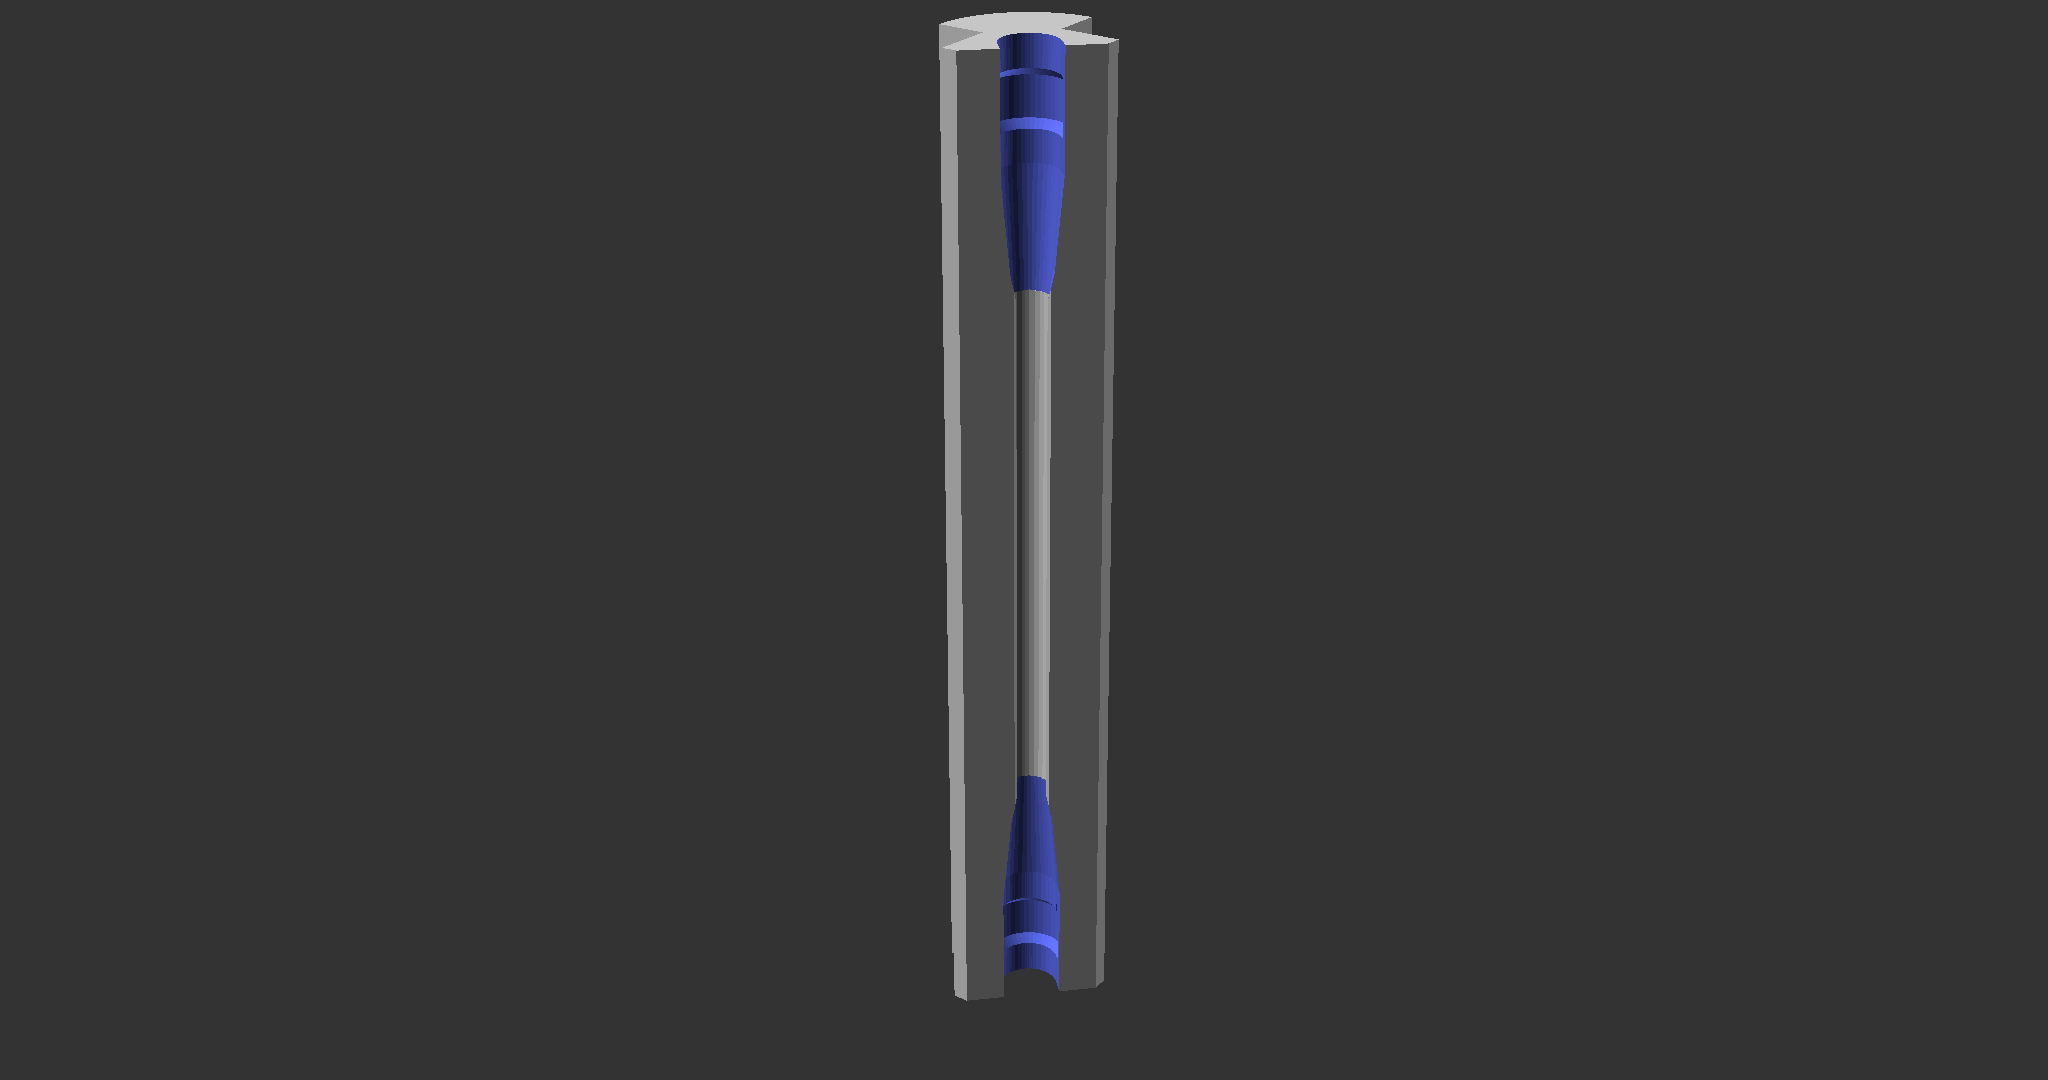

In [5]:
U = 1
FX = 1

DTF_thickness = 4.77

# These are based on the standard, don't change these
unit_width=100*U
unit_length=100*U*FX
corner_radius = 10*U
longeron_radius = 2*U

# printer settings
nozzle_diameter = 0.4
layer_height=0.2

bulkhead_thickness = 12
panel_thickness = DTF_thickness
panel_offset = 0
panel_overlap = 6
longeron_tolerance = 0.05
panel_tolerance = 0.1
greeble_tolerance = 0.05

corn = fgeom.fuselage_corner(unit_length, bulkhead_thickness, corner_radius, 
                             panel_thickness, panel_offset, panel_overlap, panel_tolerance, 
                             longeron_radius, longeron_tolerance, 
                             greeble_tolerance, 
                             nozzle_diameter)

(scad_filename, stl_filename, png_filename) = fv.solid_render(corn, 'test_fuse_output', 'tmp_corner.scad')
Image(filename=png_filename) 

C:\Program Files\OpenSCAD\openscad -o tmp_bulk.png --autocenter --viewall --render --imgsize 2048,1080 --projection p --colorscheme BeforeDawn --camera 283.58,62.37,-54.27,64.10,0.00,305.20,839.47 R:/Alex/Designs/modular_sUAS/Fuselage/tmp_bulk.stl.scad


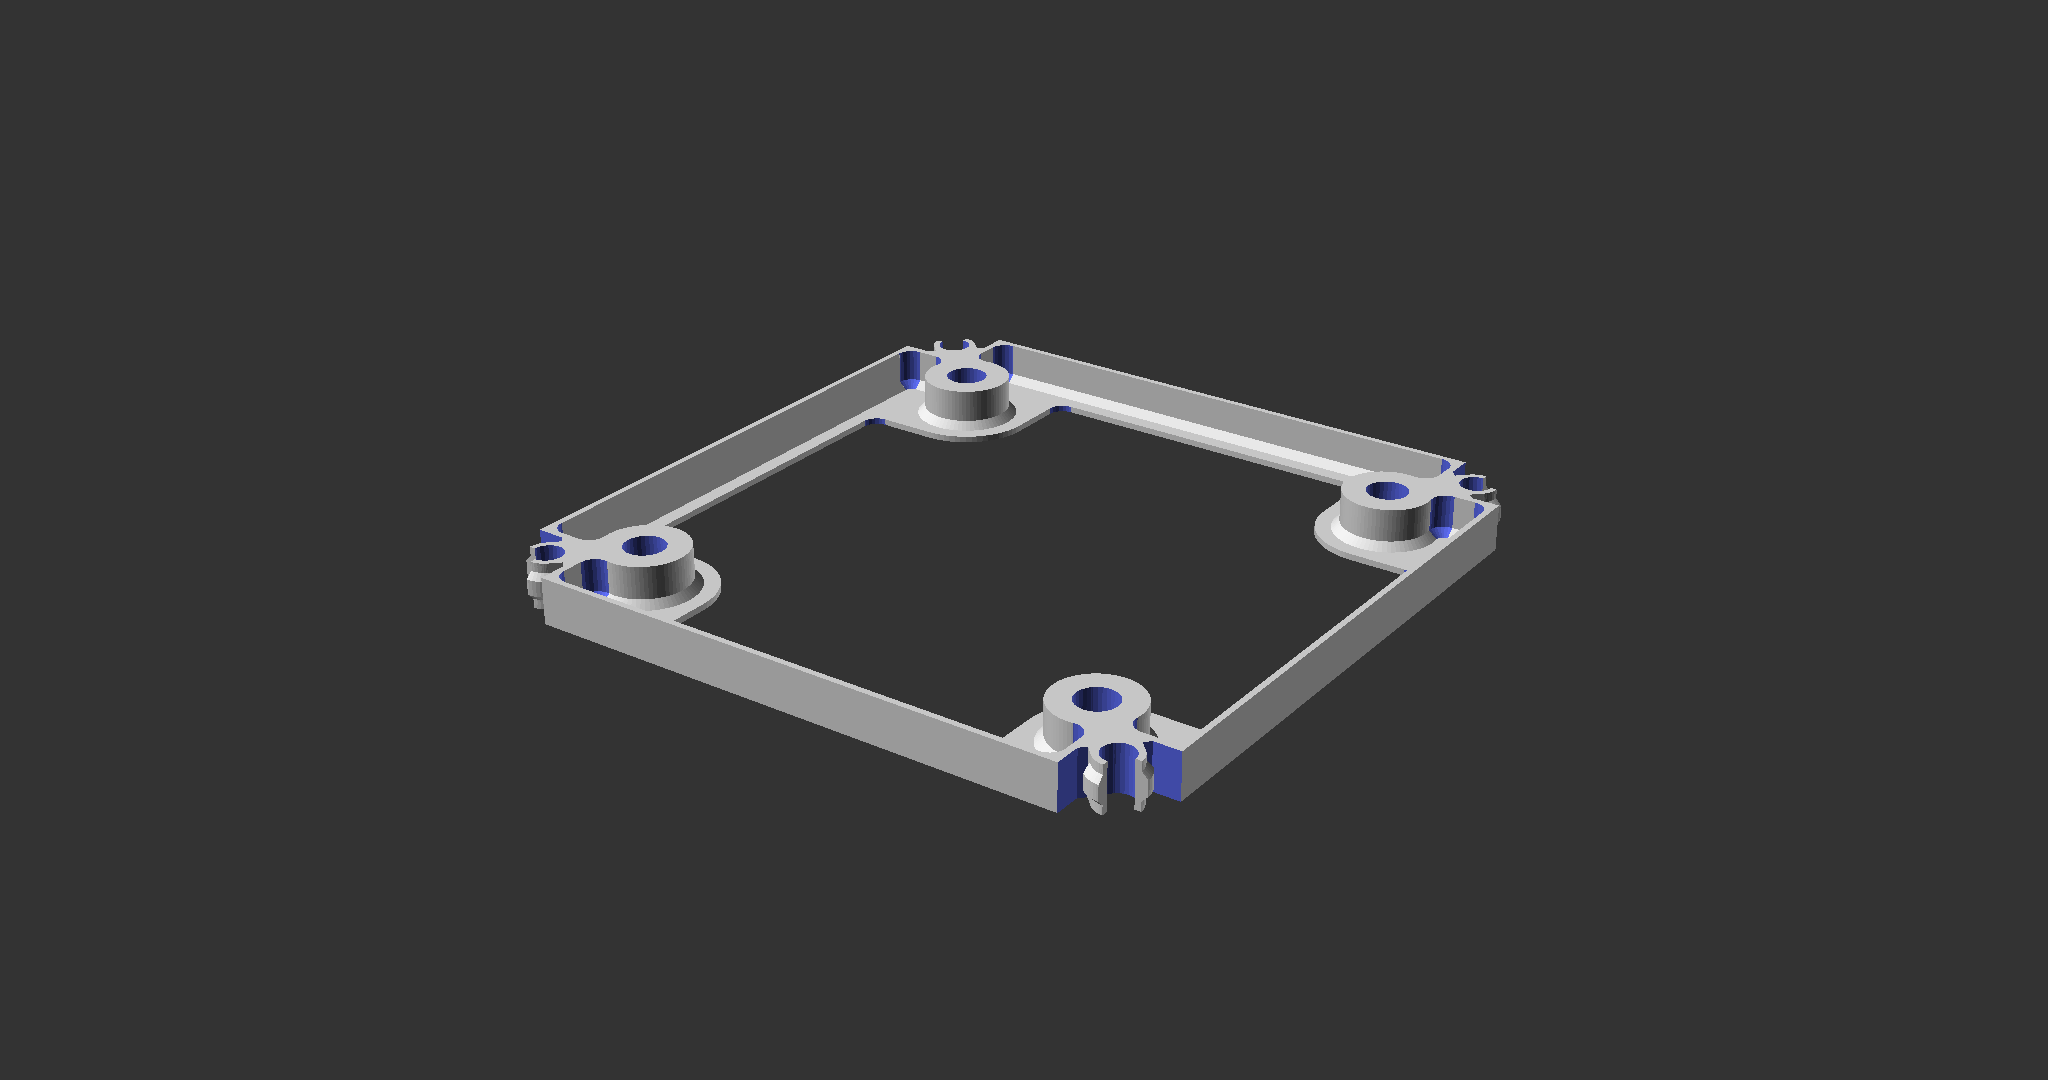

In [6]:
FX = 1
U = 1.0

DTF_thickness = 4.77

# These are based on the standard, don't change these
unit_width=100*U
unit_length=100*U*FX
corner_radius = 10*U
longeron_radius = 2*U
bolt_offset=8*U

# printer settings
nozzle_diameter = 0.4
layer_height=0.2

# User parameters
is_interconnect = False
is_cowling = False
bulkhead_thickness = 6
panel_thickness = DTF_thickness
panel_offset = 0
panel_overlap = 4
panel_tolerance = 0.1
longeron_tolerance = 0.05
# bolt_hole_radius=4.3/2
bolt_hole_radius=5.33/2
bolt_thickness=3
greeble_opening_angle = 35
greeble_tolerance = 0.0
plate_thickness=4*layer_height
web_fillet_radius=2
web_width=3
flange_fillet_radius=2
flange_thickness=2*nozzle_diameter
flange_chamfer=1

cowl_flange_height=0
cowl_flange_tolerance=0

bulk = fgeom.bulkhead_section_full(is_interconnect, is_cowling, unit_width, unit_length, 
                                   bulkhead_thickness, corner_radius, 
                                   panel_thickness, panel_offset, panel_overlap, panel_tolerance, 
                                   longeron_radius, longeron_tolerance, 
                                   bolt_hole_radius, bolt_thickness, bolt_offset, 
                                   greeble_opening_angle, greeble_tolerance,
                                   plate_thickness, 
                                   web_fillet_radius, web_width, 
                                   flange_fillet_radius, flange_thickness, flange_chamfer, 
                                   cowl_flange_height, cowl_flange_tolerance,
                                   nozzle_diameter)

(scad_filename, stl_filename, png_filename) = fv.solid_render(bulk, 'test_fuse_output', 'tmp_bulk.scad')
Image(filename=png_filename) 

C:\Program Files\OpenSCAD\openscad -o tmp_bulk_boom.png --autocenter --viewall --render --imgsize 2048,1080 --projection p --colorscheme BeforeDawn --camera 283.58,62.37,-54.27,64.10,0.00,305.20,839.47 R:/Alex/Designs/modular_sUAS/Fuselage/tmp_bulk_boom.stl.scad


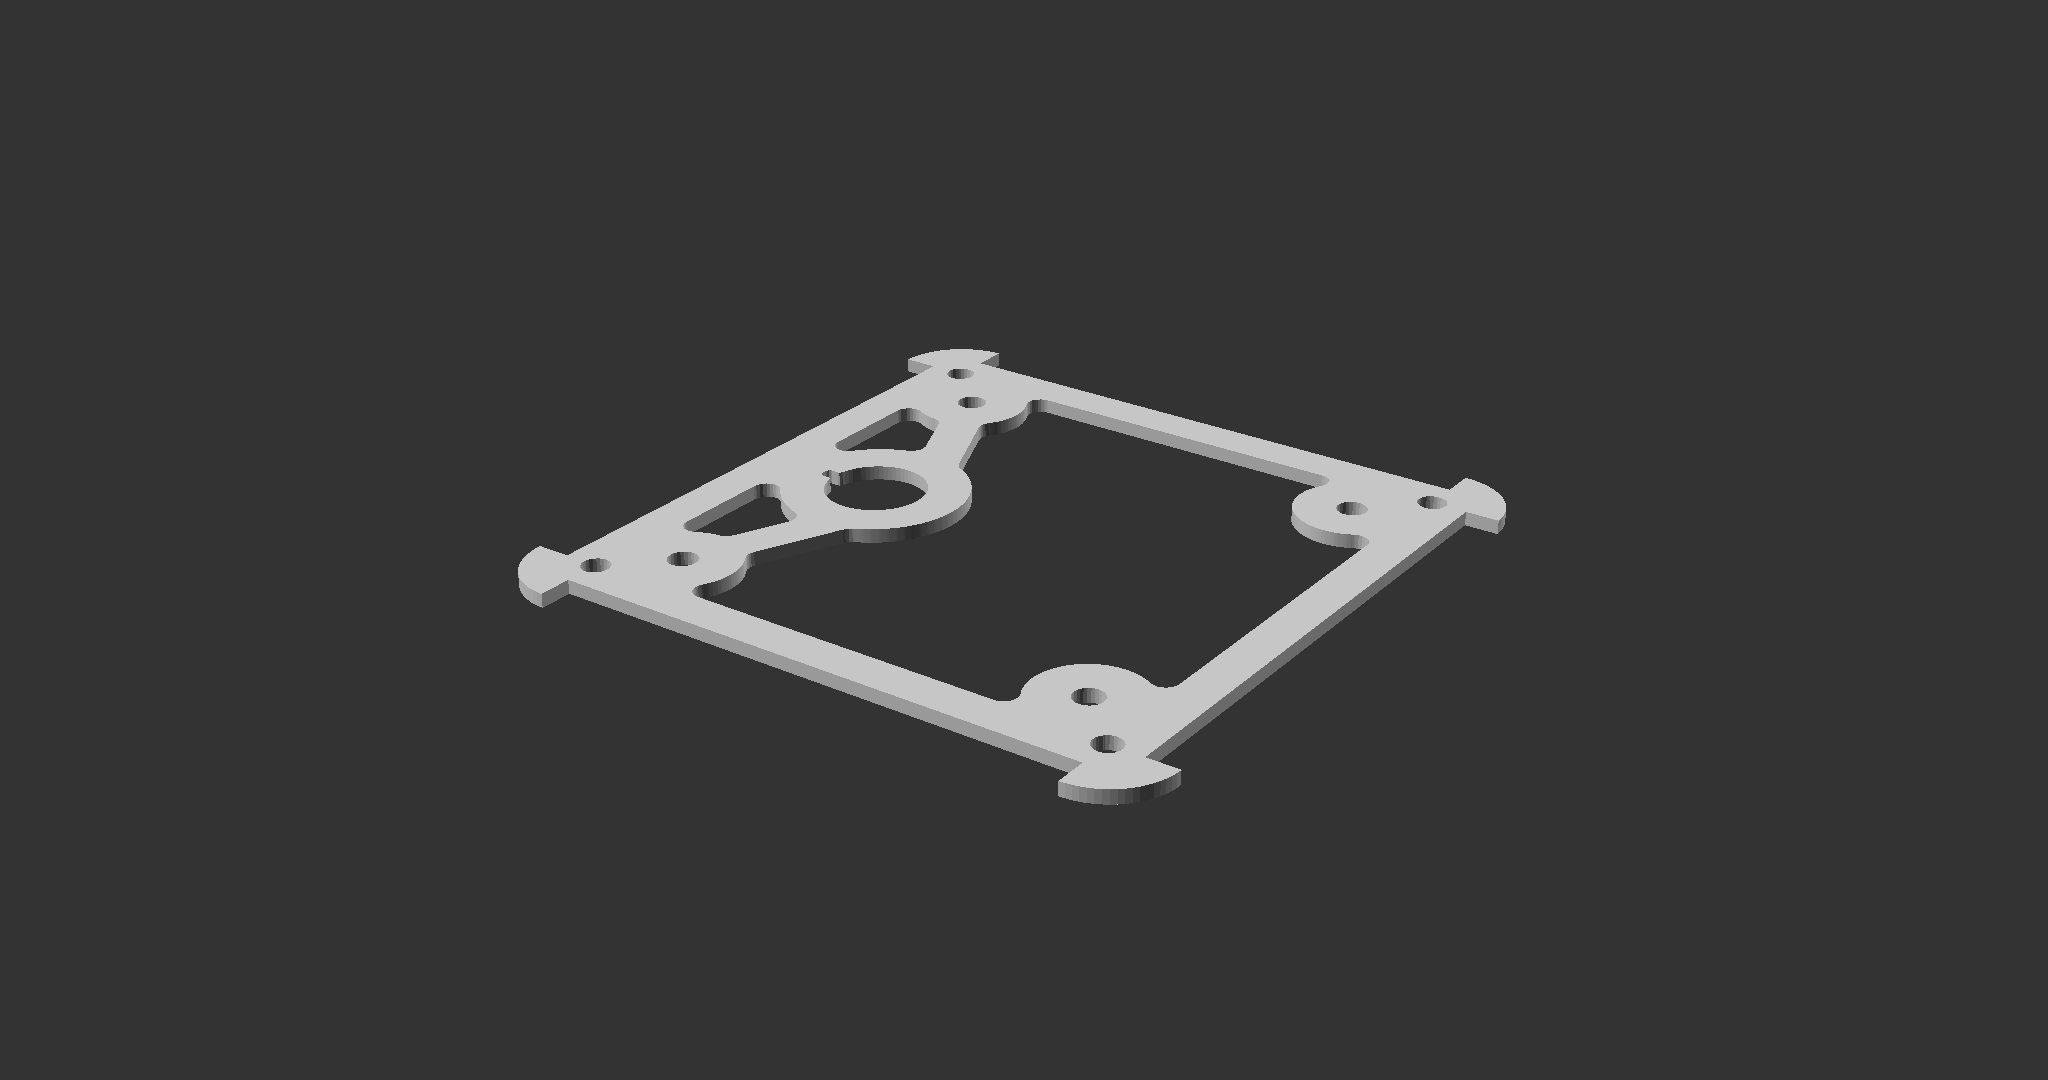

In [7]:
FX = 1;
U = 1;

DTF_thickness = 4.77;

# TODO:
#   Boom key orientation
#   External booms

# These are based on the standard, don't change these
corner_radius = 10*U;
longeron_radius = 2*U;
unit_length=100*U*FX;
unit_width=100*U;
bolt_offset=8*U;
boom_diameter=8*U;

# printer settings
nozzle_diameter = 0.4;
layer_height=0.2;

# User parameters
is_interconnect = False;
is_cowling = False;

bulkhead_thickness = 2;

panel_thickness = DTF_thickness;
panel_overlap = 4;
panel_offset = 0;
panel_tolerance = 0.1;

longeron_tolerance = 0.05;

bolt_hole_radius=4.3/2;
bolt_thickness=2;

greeble_opening_angle = 35;
greeble_tolerance = 0.0;

web_fillet_radius=2;
web_width=6;

flange_fillet_radius=2;
flange_chamfer=0;

boom_tolerance = 0.2;
boom_collet_thickness = 3;
boom_key_width = 2;
boom_key_height = 2;
boom_key_radius = 0.5;
boom_key_web_width = 6;

flange_thickness=2*nozzle_diameter;
plate_thickness=2;

# derived boom positions
boom_z_position = unit_width/2 - 0.25*unit_width;
boom_y_position = 0*unit_width;

bulk_boom = fgeom.boom_bulkhead(unit_width, corner_radius, 
                                panel_thickness, panel_offset, panel_overlap, panel_tolerance, 
                                longeron_radius, longeron_tolerance, 
                                bolt_hole_radius, bolt_offset, 
                                plate_thickness, 
                                web_fillet_radius, web_width, 
                                boom_diameter, boom_y_position, boom_z_position, boom_collet_thickness, boom_key_width, boom_key_height, boom_key_radius, boom_key_web_width, boom_tolerance);

(scad_filename, stl_filename, png_filename) = fv.solid_render(bulk_boom, 'test_fuse_output', 'tmp_bulk_boom.scad')
Image(filename=png_filename) 

C:\Program Files\OpenSCAD\openscad -o tmp_bulk_cowl.png --autocenter --viewall --render --imgsize 2048,1080 --projection p --colorscheme BeforeDawn --camera 283.58,62.37,-54.27,64.10,0.00,305.20,839.47 R:/Alex/Designs/modular_sUAS/Fuselage/tmp_bulk_cowl.stl.scad


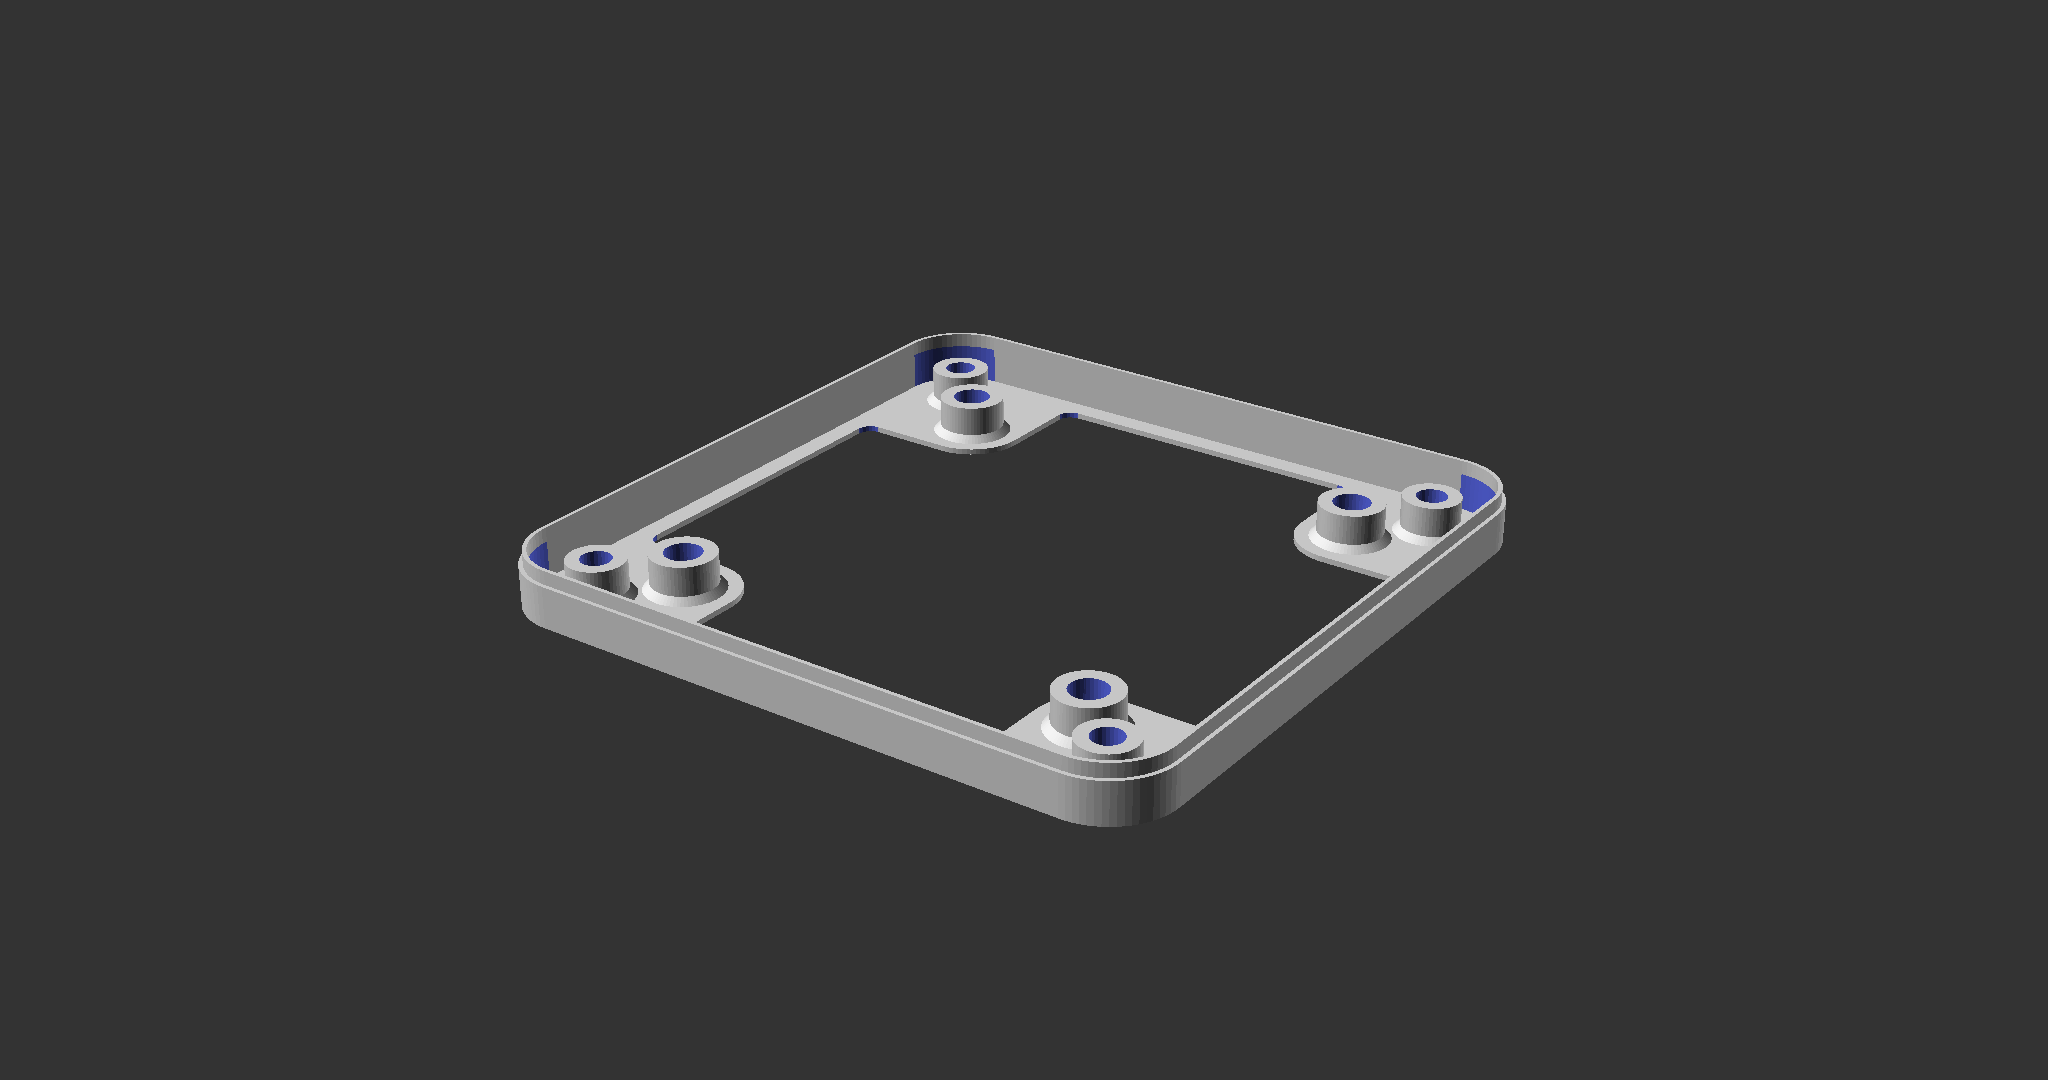

In [8]:
FX = 1
U = 1

DTF_thickness = 4.77

# These are based on the standard, don't change these
corner_radius = 10*U
longeron_radius = 2*U+0.15
unit_length=100*U*FX
unit_width=100*U
bolt_offset=8*U

# printer settings
nozzle_diameter = 0.4
layer_height=0.2

# User parameters
is_interconnect = False
is_cowling = True

bulkhead_thickness = 6

panel_thickness = 0
panel_overlap = 0
panel_offset = 0
panel_tolerance = 0.0

longeron_tolerance = 0.05

#bolt_hole_radius=4.3/2
bolt_hole_radius=5.33/2
bolt_thickness=2

greeble_opening_angle = 35
greeble_tolerance = 0.0

web_fillet_radius=2
web_width=3

flange_fillet_radius=2
flange_chamfer=1

cowl_flange_height=2
cowl_flange_tolerance=0.2

flange_thickness=3*nozzle_diameter
plate_thickness=4*layer_height

bulk_cowl = fgeom.bulkhead_section_full(is_interconnect, is_cowling, unit_width, unit_length, 
                      bulkhead_thickness, corner_radius, 
                      panel_thickness, panel_offset, panel_overlap, panel_tolerance, 
                      longeron_radius, longeron_tolerance, 
                      bolt_hole_radius, bolt_thickness, bolt_offset, 
                      greeble_opening_angle, greeble_tolerance,
                      plate_thickness, 
                      web_fillet_radius, web_width, 
                      flange_fillet_radius, flange_thickness, flange_chamfer, 
                      cowl_flange_height, cowl_flange_tolerance,
                      nozzle_diameter)

(scad_filename, stl_filename, png_filename) = fv.solid_render(bulk_cowl, 'test_fuse_output', 'tmp_bulk_cowl.scad')
Image(filename=png_filename) 

C:\Program Files\OpenSCAD\openscad -o tmp_nose_cowl.png --autocenter --viewall --render --imgsize 2048,1080 --projection p --colorscheme BeforeDawn --camera 283.58,62.37,-54.27,64.10,0.00,305.20,839.47 R:/Alex/Designs/modular_sUAS/Fuselage/tmp_nose_cowl.stl.scad


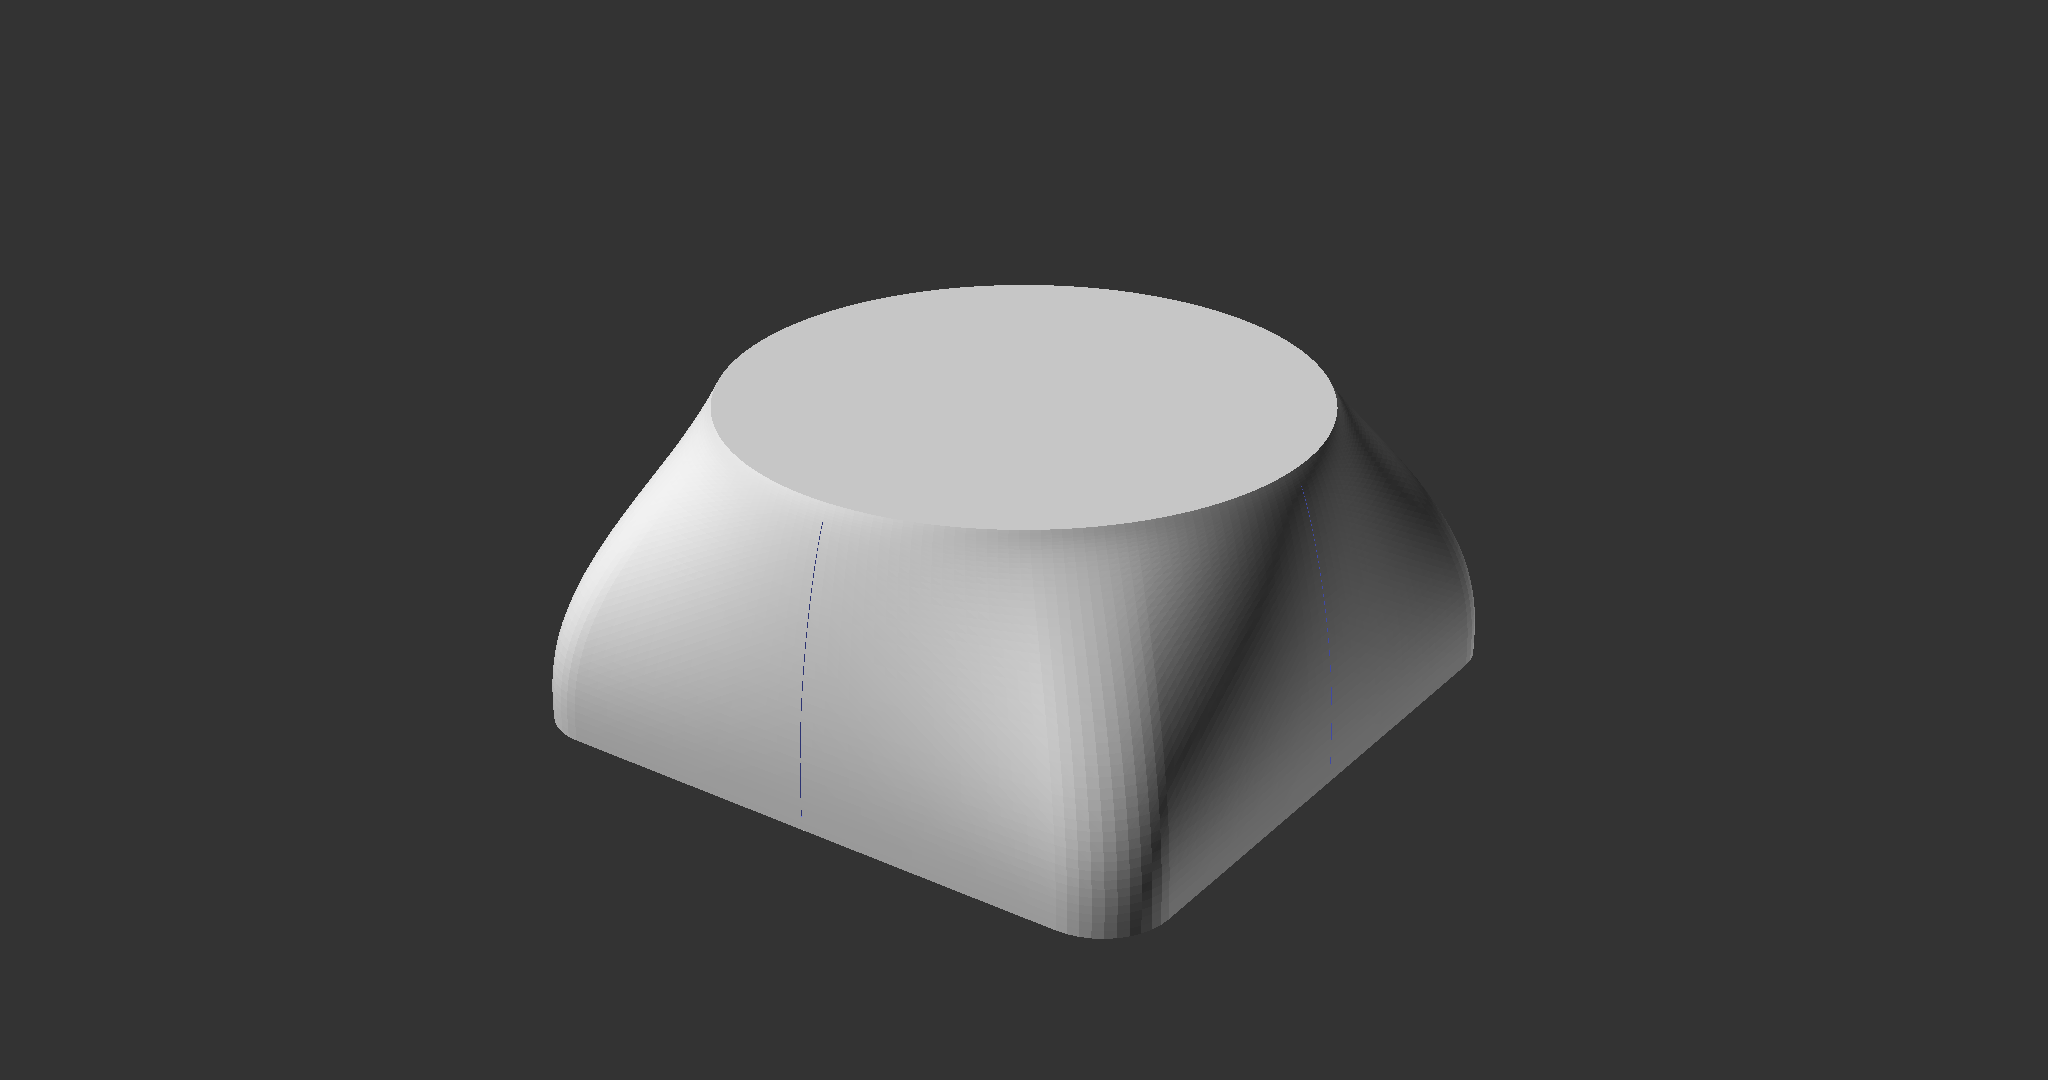

In [9]:


U = 1

plate_diam = U*60
plate_tol = 0.1
plate_thickness = 0.8
plate_flange_width = 2
cone_angle = 35

nose_len = U*50
cut_len = U*6
unit_width = U*100
nose_flange_inset = 0.5
nose_flange_height = 1.0
plate_flange_height = 1.0

buttress_z_offset = U*2
buttress_r_start = U*0
buttress_r_end = U*6.6
buttress_r_inset = U*3
buttress_thickness = 0.05

oml_filename="vsp_nose.stl"
oml_scale=1e-3
oml_length = 0.050
oml_offset_x=0
oml_reversed = False

nose_cowl = fcowl.nose_cowl(U, unit_width, 
                            oml_filename, oml_scale, oml_length, oml_offset_x, oml_reversed, 
                            cut_len, 
                            buttress_thickness, buttress_z_offset, buttress_r_start, buttress_r_end, buttress_r_inset, 
                            cone_angle)

(scad_filename, stl_filename, png_filename) = fv.solid_render(nose_cowl, 'test_fuse_output', 'tmp_nose_cowl.scad')
Image(filename=png_filename) 

C:\Program Files\OpenSCAD\openscad -o tmp_nose.png --autocenter --viewall --render --imgsize 2048,1080 --projection p --colorscheme BeforeDawn --camera 283.58,62.37,-54.27,64.10,0.00,305.20,839.47 R:/Alex/Designs/modular_sUAS/Fuselage/tmp_nose.stl.scad


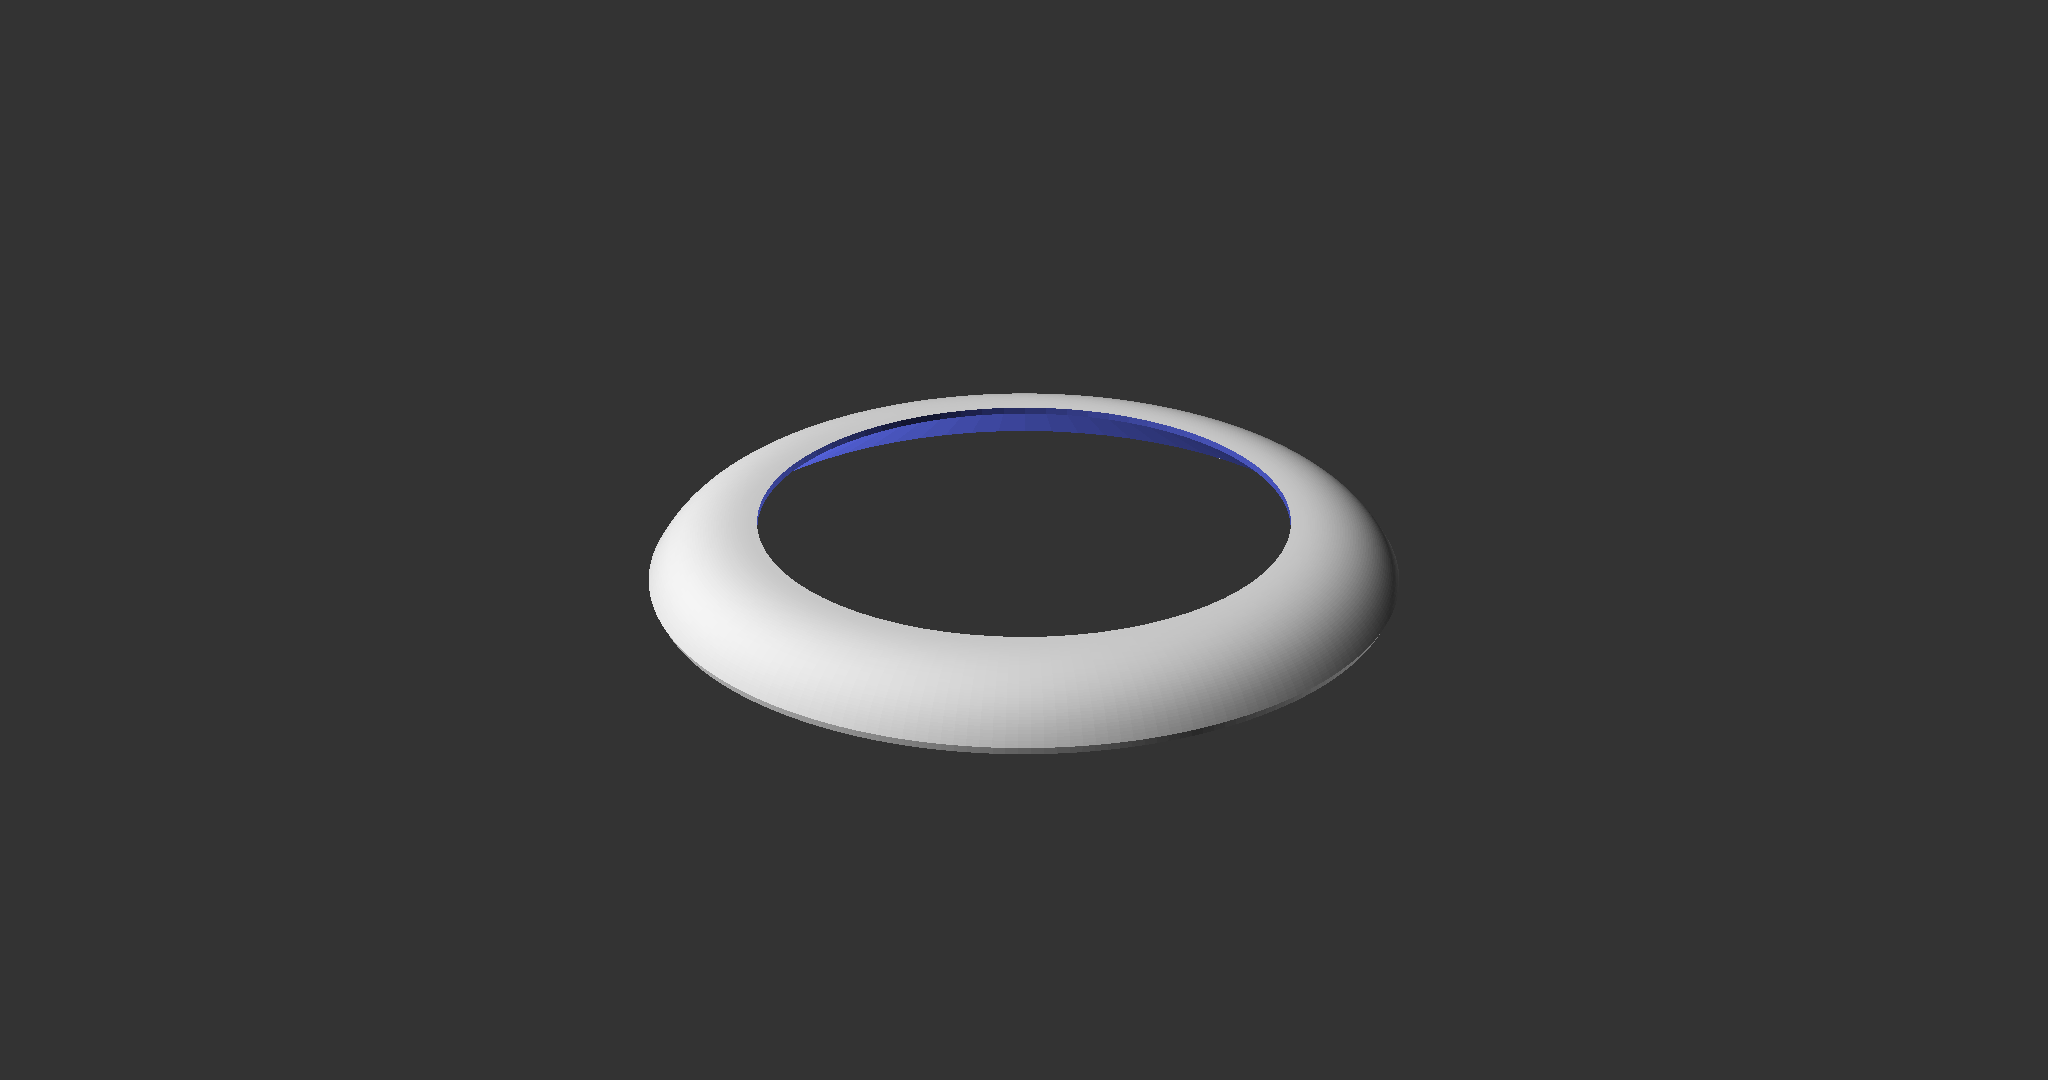

In [10]:
U = 1

plate_diam = U*60
plate_tol = 0.1
plate_thickness = 0.8
plate_flange_width = 2
cone_angle = 35

nose_len = U*50
cut_len = U*6
unit_width = U*100
nose_flange_inset = 0.5
nose_flange_height = 1.0
plate_flange_height = 1.0

buttress_z_offset = U*2
buttress_r_start = U*0
buttress_r_end = U*6.6
buttress_r_inset = U*3
buttress_thickness = 0.05

oml_filename="vsp_nose.stl"
oml_scale=1e-3
oml_length = 0.050
oml_offset_x=0
oml_reversed = False

nose = fcowl.nose(U, unit_width, 
                       oml_filename, oml_scale, oml_offset_x, oml_reversed, 
                       cut_len, 
                       nose_flange_height, nose_flange_inset, 
                       plate_diam, plate_thickness, plate_tol, 
                       cone_angle)

(scad_filename, stl_filename, png_filename) = fv.solid_render(nose, 'test_fuse_output', 'tmp_nose.scad')
Image(filename=png_filename) 

C:\Program Files\OpenSCAD\openscad -o tmp_nose_plate.png --autocenter --viewall --render --imgsize 2048,1080 --projection p --colorscheme BeforeDawn --camera 283.58,62.37,-54.27,64.10,0.00,305.20,839.47 R:/Alex/Designs/modular_sUAS/Fuselage/tmp_nose_plate.stl.scad


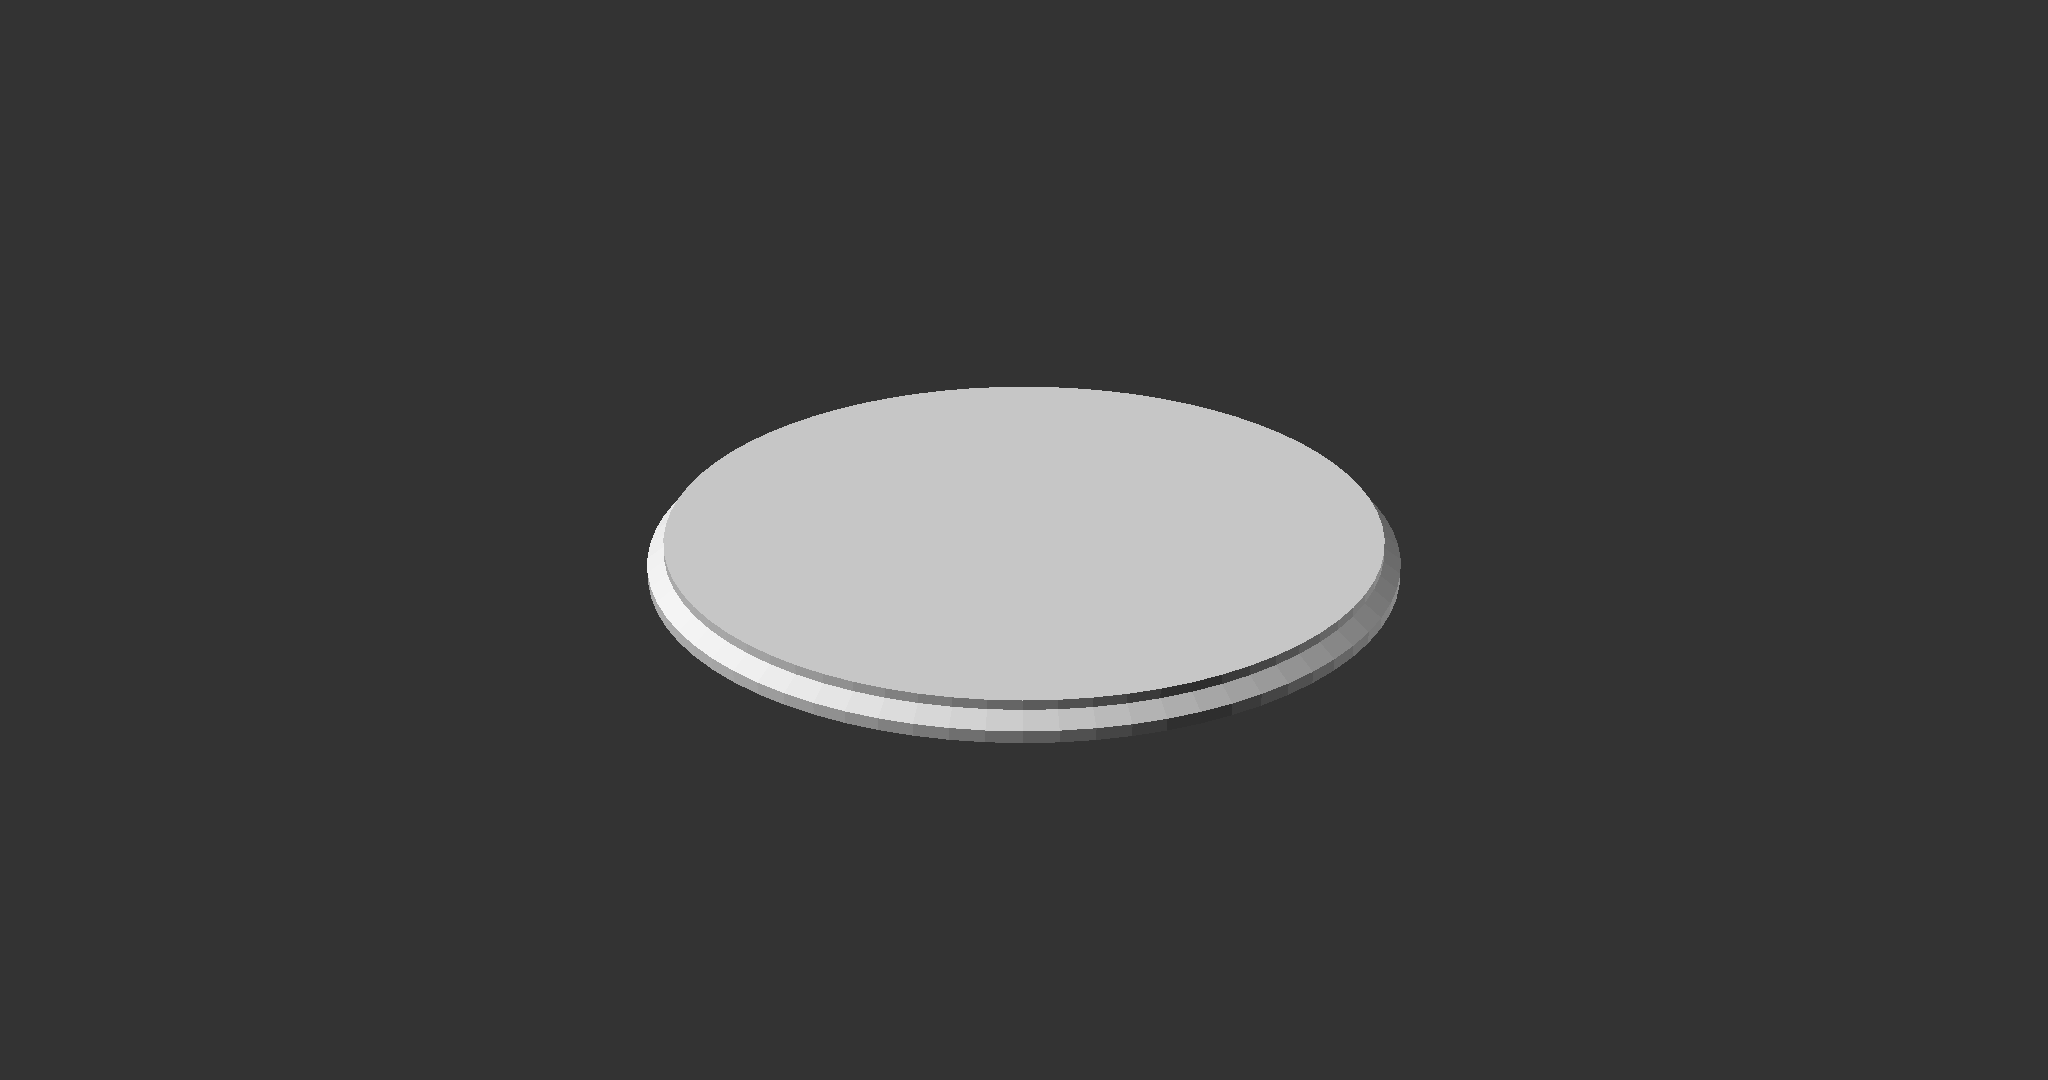

In [11]:
U = 1

plate_diam = U*60
plate_tol = 0.1
plate_thickness = 0.8
plate_flange_width = 2
cone_angle = 35

nose_len = U*50
cut_len = U*6
unit_width = U*100
nose_flange_inset = 0.5
nose_flange_height = 1.0
plate_flange_height = 1.0

buttress_z_offset = U*2
buttress_r_start = U*0
buttress_r_end = U*6.6
buttress_r_inset = U*3
buttress_thickness = 0.05

oml_filename="vsp_nose.stl"
oml_scale=1e-3
oml_length = 0.050
oml_offset_x=0
oml_reversed = False

nose_plate = fcowl.nose_plate(plate_diam, plate_thickness, plate_flange_width, plate_flange_height, cone_angle)

(scad_filename, stl_filename, png_filename) = fv.solid_render(nose_plate, 'test_fuse_output', 'tmp_nose_plate.scad')
Image(filename=png_filename) 

C:\Program Files\OpenSCAD\openscad -o tmp_full_nose.png --autocenter --viewall --render --imgsize 2048,1080 --projection p --colorscheme BeforeDawn --camera 283.58,62.37,-54.27,64.10,0.00,305.20,839.47 R:/Alex/Designs/modular_sUAS/Fuselage/tmp_full_nose.stl.scad


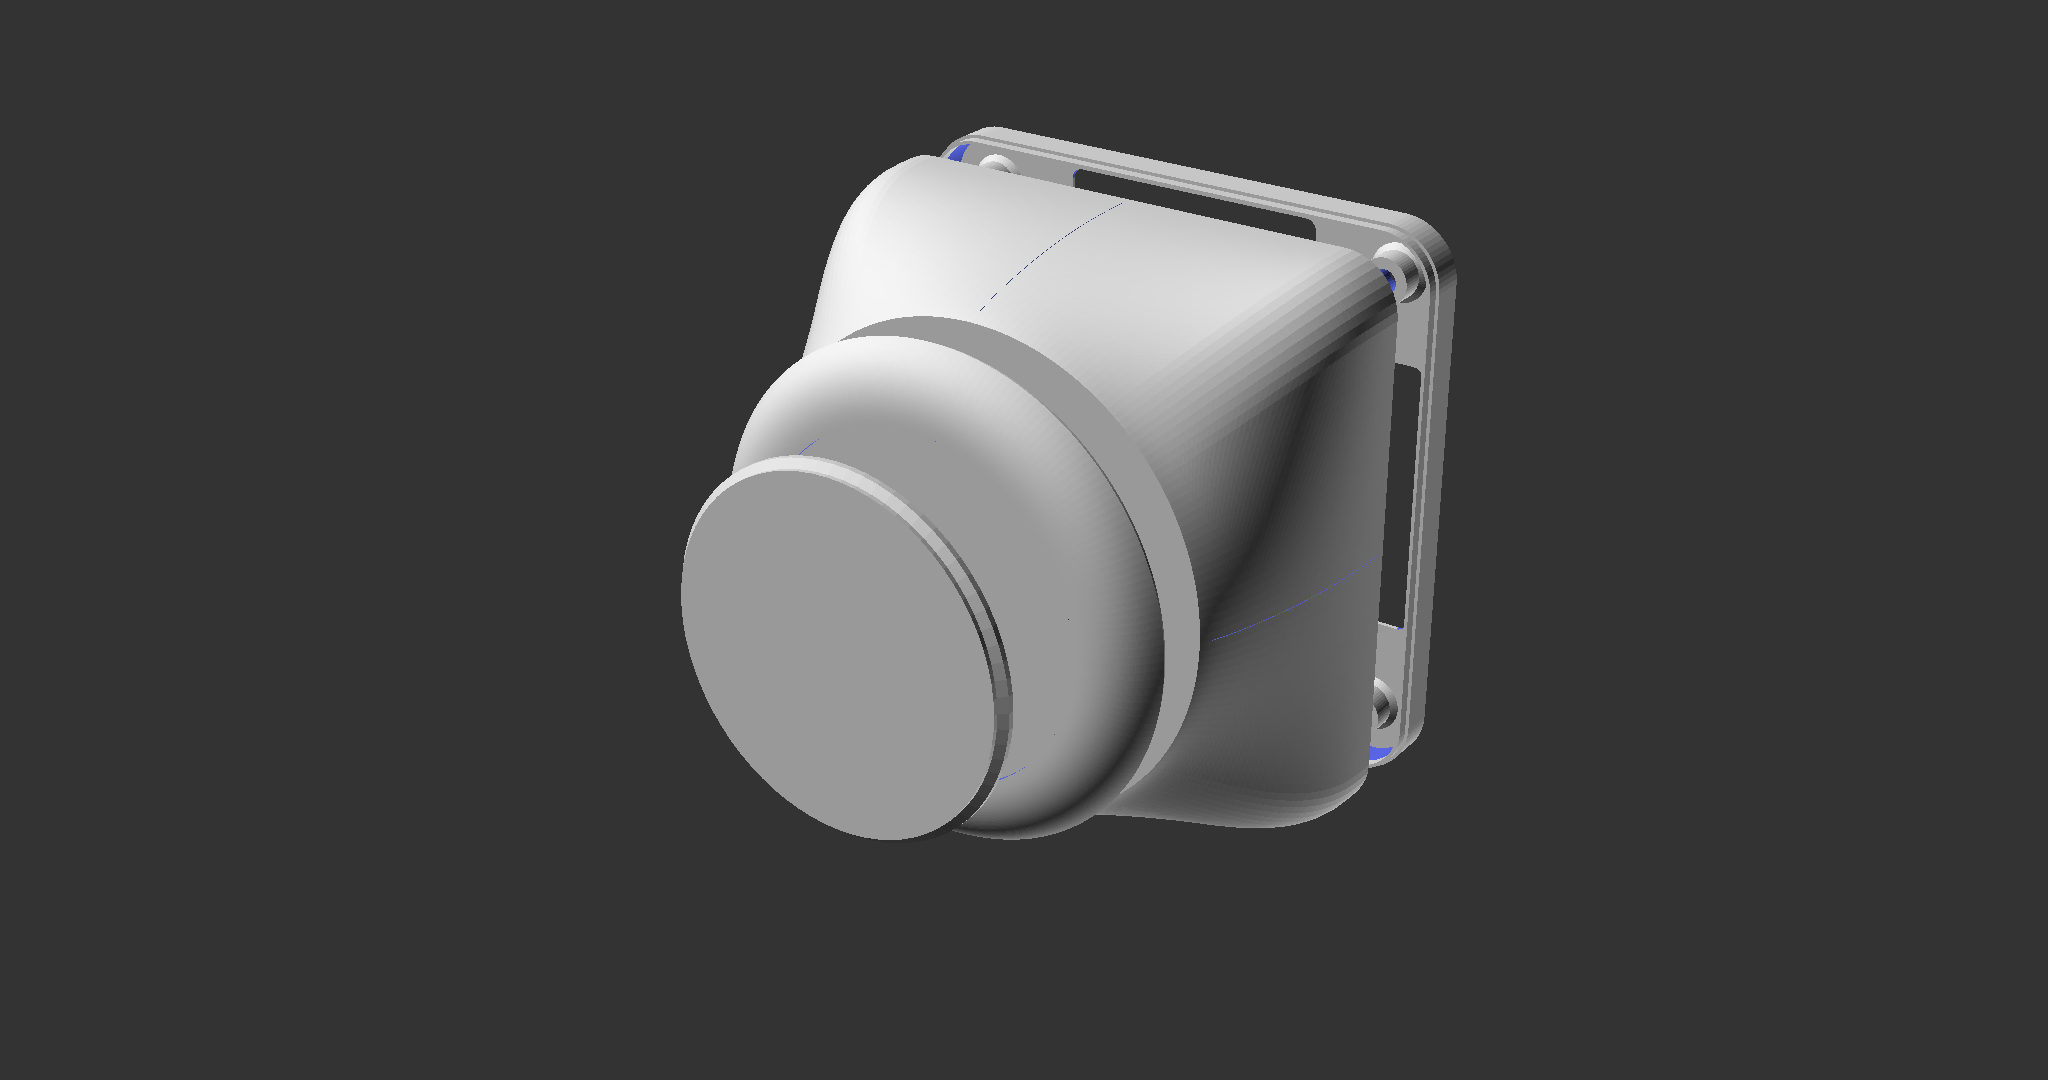

In [12]:
full_nose = solid2.rotate([0,-90,0]) (
    nose_plate
    + solid2.translate([0,0,-24])(nose)
    + solid2.translate([0,0,-30])(nose_cowl) 
    + solid2.translate([0,0,-100])(bulk_cowl)
)
(scad_filename, stl_filename, png_filename) = fv.solid_render(full_nose, 'test_fuse_output', 'tmp_full_nose.scad')
Image(filename=png_filename)

C:\Program Files\OpenSCAD\openscad -o tmp_tail_cowl.png --autocenter --viewall --render --imgsize 2048,1080 --projection p --colorscheme BeforeDawn --camera 283.58,62.37,-54.27,64.10,0.00,305.20,839.47 R:/Alex/Designs/modular_sUAS/Fuselage/tmp_tail_cowl.stl.scad


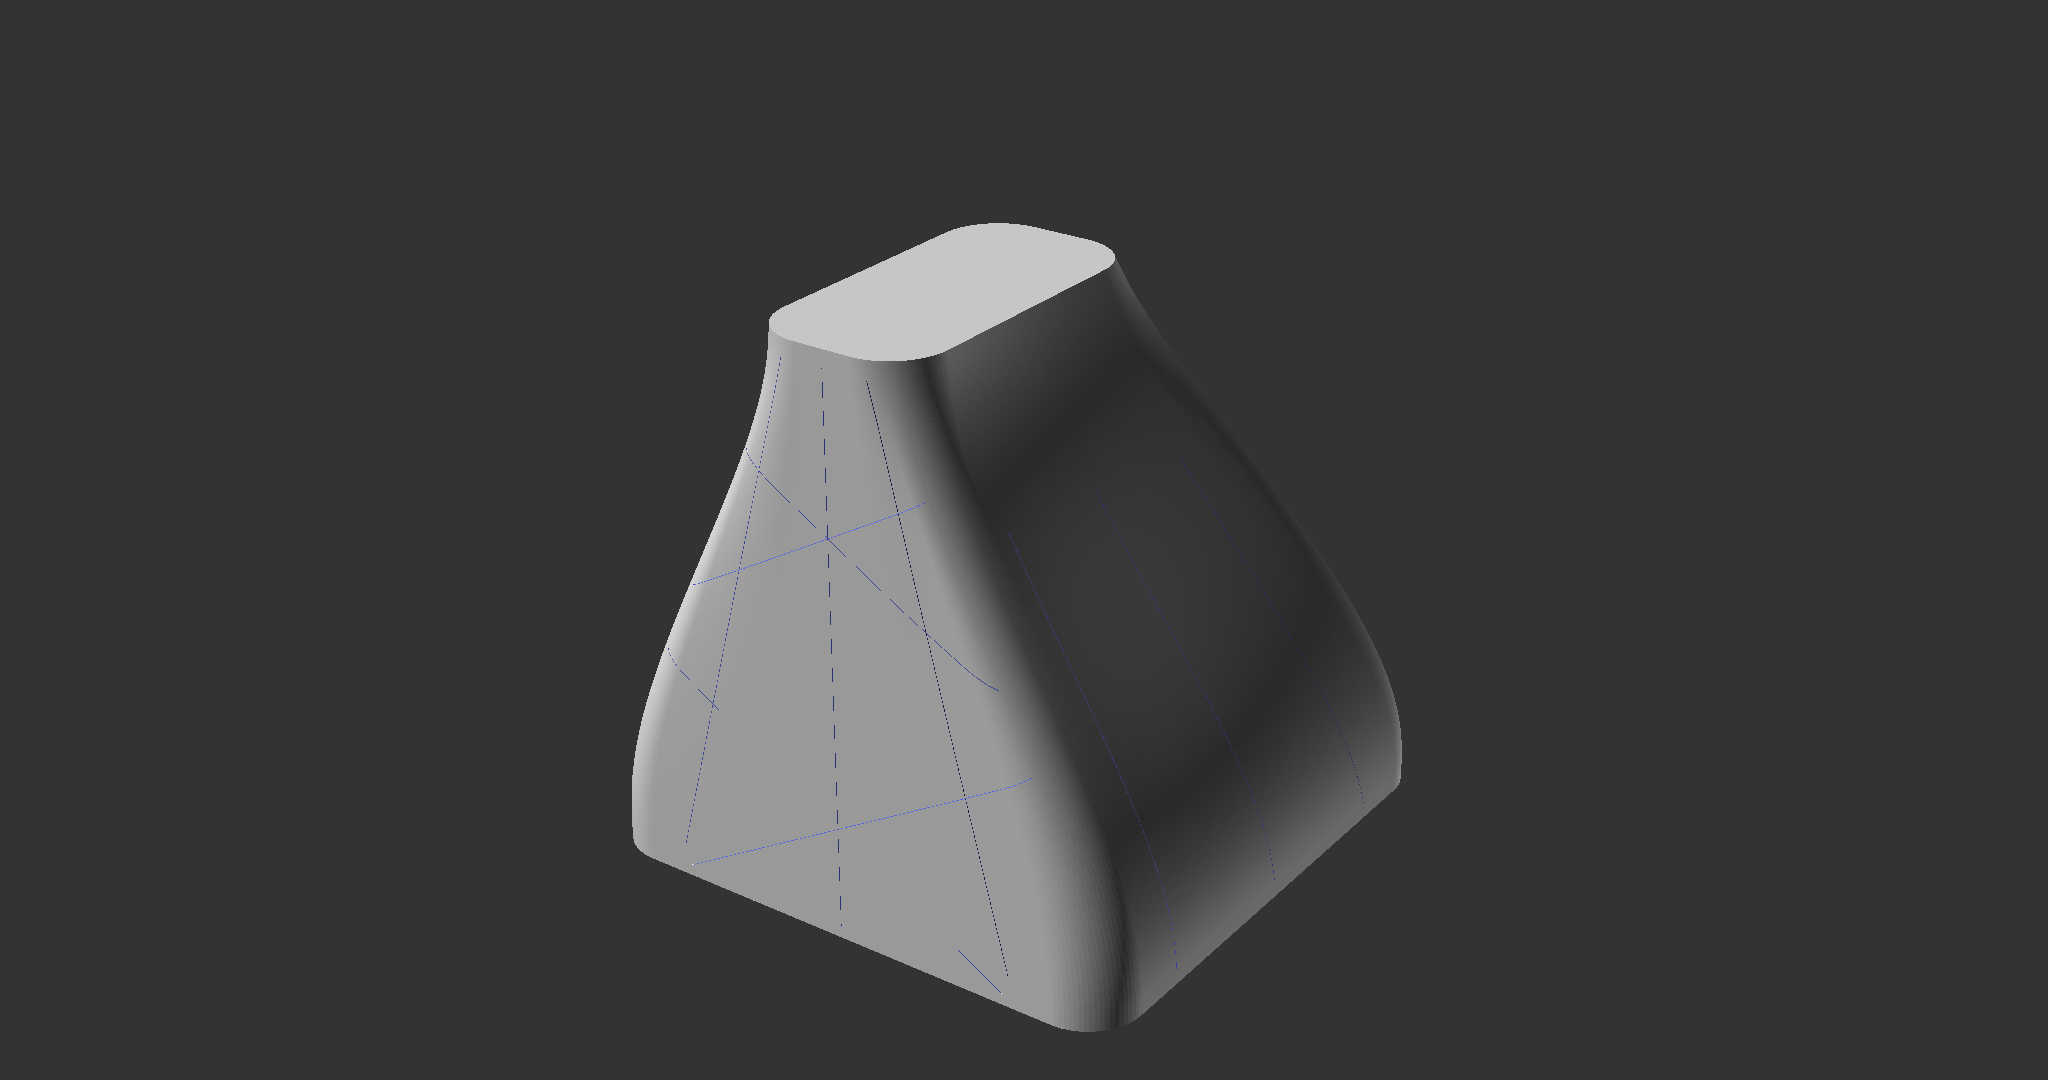

In [13]:
U = 1;

unit_width = U*100;
#tail_len = U*100;
cut_len = 0;

plate_diam = U*60;
plate_thickness = 0.8;
plate_flange_width = 2;
plate_flange_height = 1.0;
plate_tol = 0.1;

cone_angle = 35;
flange_inset = 0.5;
tail_flange_height = 1.0;

buttress_z_offset = U*2;
buttress_r_inset = U*5;
buttress_thickness = 0.05;

side_buttress_z_end = U*25;
side_buttress_r_start = U*0;
side_buttress_r_end = U*23.3; # U*32.1;

top_buttress_z_end = U*3;
top_buttress_r_start = U*0;
top_buttress_r_end = U*0;

top_diag_buttress_z_start = U*20;
top_diag_buttress_depth = U*2;

bottom_buttress_z_end = U*20;
bottom_buttress_r_start = U*0;
bottom_buttress_r_end = U*28.8; # U*38.3;

oml_filename = "vsp_tail.stl";
oml_scale = 1e-3;
oml_length = 0.1;
oml_offset_x = -0.25;

tail_cowl = fcowl.tail_cowl(U, unit_width, 
                            oml_filename, oml_scale, oml_length, oml_offset_x, 
                            cut_len, 
                            buttress_thickness, buttress_z_offset, buttress_r_inset, 
                            side_buttress_z_end, side_buttress_r_start, side_buttress_r_end, 
                            top_buttress_z_end, top_buttress_r_start, top_buttress_r_end, 
                            bottom_buttress_z_end, bottom_buttress_r_start, bottom_buttress_r_end, 
                            top_diag_buttress_depth, top_diag_buttress_z_start, 
                            cone_angle);

(scad_filename, stl_filename, png_filename) = fv.solid_render(tail_cowl, 'test_fuse_output', 'tmp_tail_cowl.scad')
Image(filename=png_filename) 

C:\Program Files\OpenSCAD\openscad -o tmp_full_tail.png --autocenter --viewall --render --imgsize 2048,1080 --projection p --colorscheme BeforeDawn --camera 283.58,62.37,-54.27,64.10,0.00,305.20,839.47 R:/Alex/Designs/modular_sUAS/Fuselage/tmp_full_tail.stl.scad


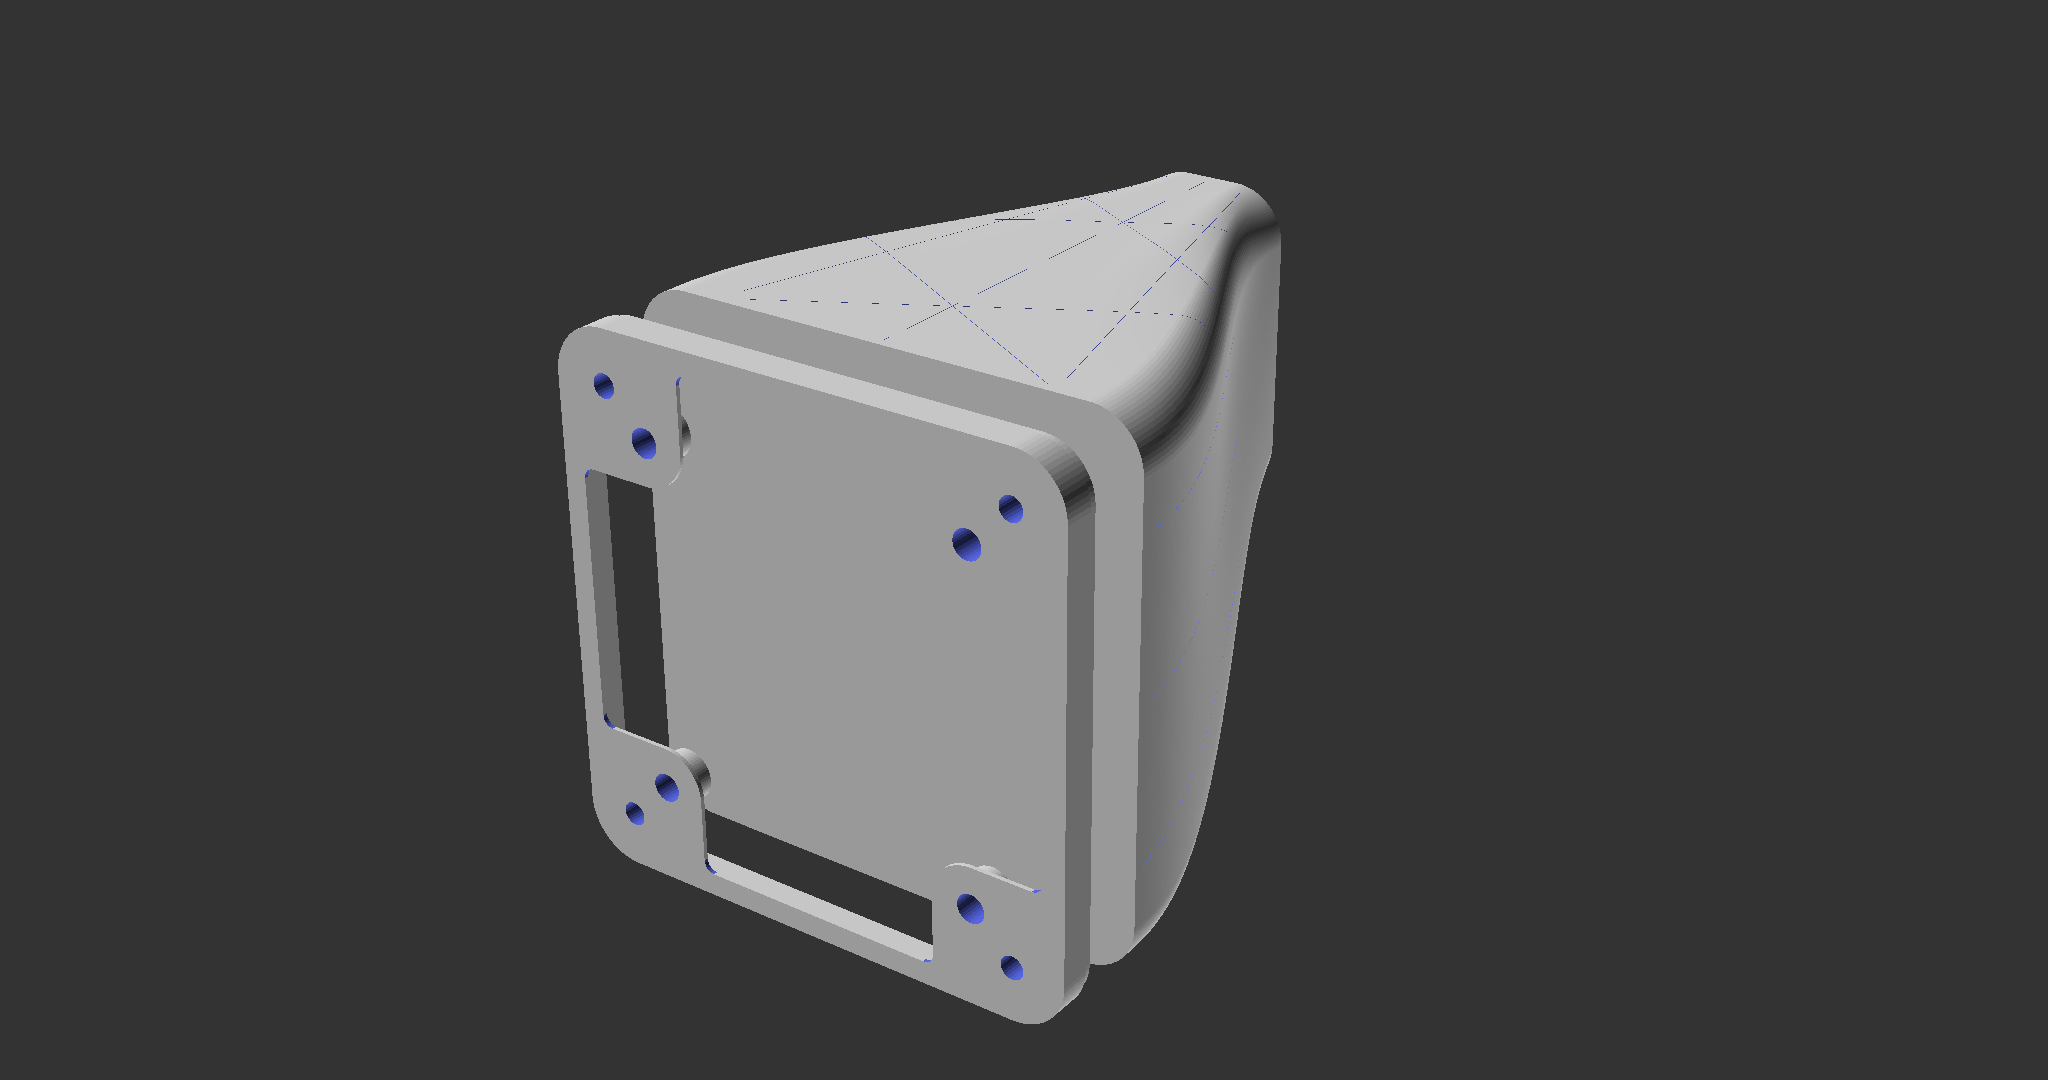

In [14]:
full_tail = solid2.rotate([0,-90,0]) (solid2.rotate([0,180,0])(bulk_cowl + solid2.translate([0,0,120])(tail_cowl) ) )
             
(scad_filename, stl_filename, png_filename) = fv.solid_render(full_tail, 'test_fuse_output', 'tmp_full_tail.scad')
Image(filename=png_filename)

In [15]:
def unit_frame():
    U = 1
    FX = 1

    DTF_thickness = 4.77

    # These are based on the standard, don't change these
    unit_width=100*U
    unit_length=100*U*FX
    corner_radius = 10*U
    longeron_radius = 2*U
    bolt_offset=8*U

    # printer settings
    nozzle_diameter = 0.4
    layer_height=0.2

    # User parameters
    bulkhead_thickness = 6
    corner_radius = 10*U
    panel_thickness = DTF_thickness
    panel_offset = 0
    panel_overlap = 4
    panel_tolerance = 0.1

    longeron_tolerance = 0.05

    # bolt_hole_radius=4.3/2
    bolt_hole_radius=5.33/2
    bolt_thickness=3

    greeble_opening_angle = 35
    greeble_tolerance = 0.0
    greeble_tolerance = 0.05

    plate_thickness=4*layer_height

    web_fillet_radius=2
    web_width=3

    flange_fillet_radius=2
    flange_thickness=2*nozzle_diameter
    flange_chamfer=1

    corn = fgeom.fuselage_corner(unit_length, bulkhead_thickness, corner_radius, 
                             panel_thickness, panel_offset, panel_overlap, panel_tolerance, 
                             longeron_radius, longeron_tolerance, 
                             greeble_tolerance, 
                             nozzle_diameter)

    is_interconnect = False
    is_cowling = False

    bulk = fgeom.bulkhead_section_full(is_interconnect, is_cowling, unit_width, unit_length, 
                                   bulkhead_thickness, corner_radius, 
                                   panel_thickness, panel_offset, panel_overlap, panel_tolerance, 
                                   longeron_radius, longeron_tolerance, 
                                   bolt_hole_radius, bolt_thickness, bolt_offset, 
                                   greeble_opening_angle, greeble_tolerance,plate_thickness, 
                                   web_fillet_radius, web_width, 
                                   flange_fillet_radius, flange_thickness, flange_chamfer, 
                                   cowl_flange_height, cowl_flange_tolerance,
                                   nozzle_diameter)


    frame = bulk 
    frame += solid2.translate([0,0,unit_length]) ( solid2.mirror([0,0,-1])(bulk) )
    frame += solid2.translate([unit_width/2-corner_radius, unit_width/2-corner_radius, 0]) (corn)
    frame += solid2.mirror([-1,0,0])(solid2.translate([unit_width/2-corner_radius, unit_width/2-corner_radius, 0]) (corn))
    frame += solid2.mirror([0,-1,0])(solid2.translate([unit_width/2-corner_radius, unit_width/2-corner_radius, 0]) (corn))
    frame += solid2.mirror([-1,-1,0])(solid2.translate([unit_width/2-corner_radius, unit_width/2-corner_radius, 0]) (corn))
    frame = solid2.rotate(0,-90,0)(frame)

    return frame

C:\Program Files\OpenSCAD\openscad -o tmp_splode.png --autocenter --viewall --render --imgsize 2048,1080 --projection p --colorscheme BeforeDawn --camera 283.58,62.37,-54.27,64.10,0.00,305.20,839.47 R:/Alex/Designs/modular_sUAS/Fuselage/tmp_splode.stl.scad


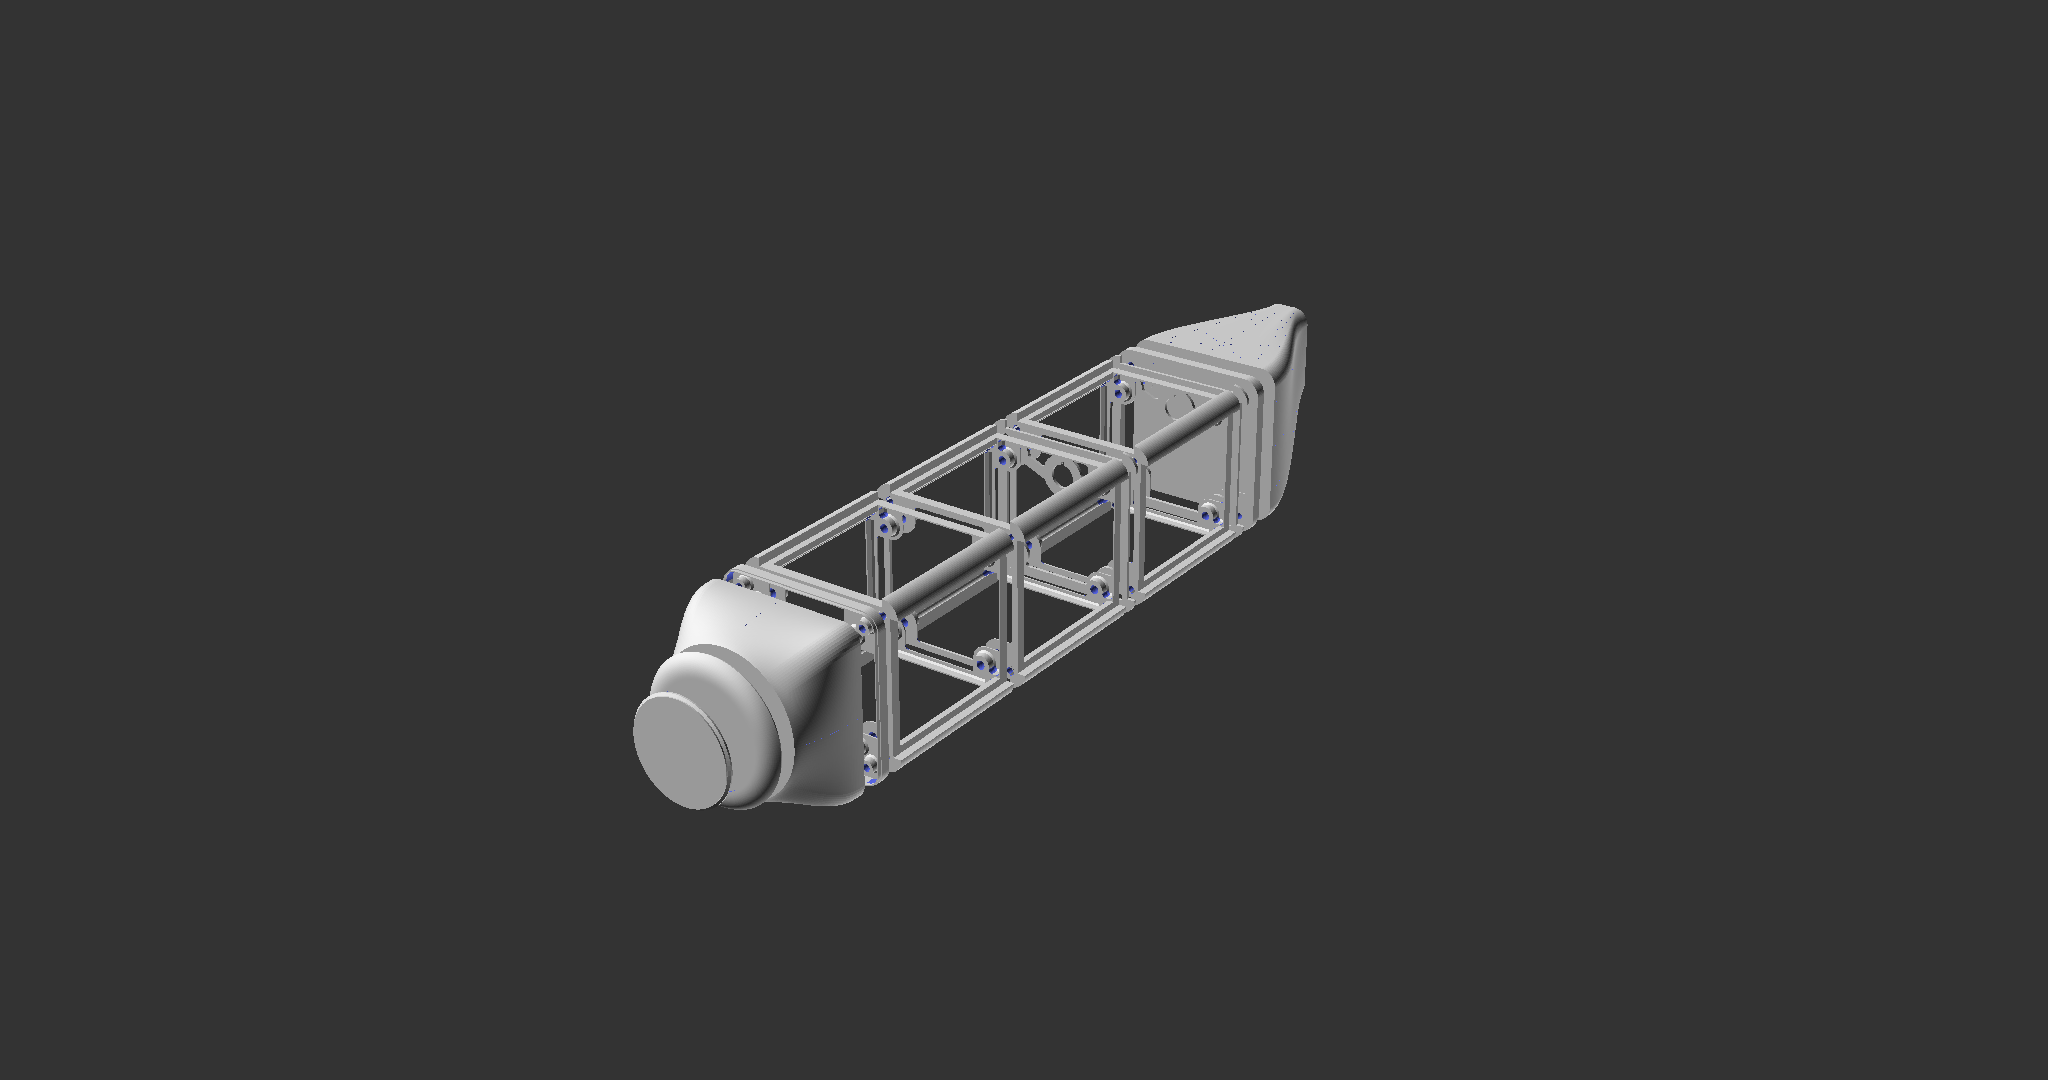

In [16]:

frame = unit_frame()

(scad_filename, stl_filename, png_filename) = fv.solid_render(full_nose 
                                                           + solid2.translate([100+100+10,0,0])(frame) 
                                                           + solid2.translate([100+200+20,0,0])(frame) 
                                                           + solid2.rotate([90,0,0])(solid2.translate([+100+200+30,0,0])(solid2.rotate([0,-90,0])(bulk_boom)))
                                                           + solid2.translate([+100+300+40,0,0])(frame) 
                                                           + solid2.rotate([90,0,0])(solid2.translate([+100+300+50,0,0])(solid2.rotate([0,-90,0])(bulk_boom)))
                                                           + solid2.translate([+100+300+60,0,0])(full_tail)
                                                           , 'test_fuse_output', 'tmp_splode.scad')
Image(filename=png_filename)